# Reto 2 · Fenotipado digital de secuelas post-infecciosas

En este notebook resumimos el proyecto. Buscamos fenotipos de secuelas tras una infección respiratoria grave que se mantengan al cambiar de cohorte, vemos cómo evolucionan en el tiempo y si se pueden predecir. Trabajamos con cuatro cohortes (CIBERESUCICOVID, POSTCOVID-Lleida, TENACITY y Virgen del Rocío), con 9.809 pacientes en total.

Cada paso está desarrollado con más detalle en los notebooks 01–08 (ver `README.md`).

## Índice

- [0. Configuración del entorno](#0.-Configuración-del-entorno)
- [1. Limpieza de datos](#1.-Limpieza-de-datos)
- [2. Clusterización](#2.-Clusterización)
  - [2.1. Clusterización en el dataset CIBERESUCICOVID](#2.1.-Clusterización-en-el-dataset-CIBERESUCICOVID)
  - [2.2 Clusterización en todos los datasets](#2.2-Clusterización-en-todos-los-datasets)
- [3. Trayectorias](#3.-Trayectorias)
- [4. Predicción](#4.-Predicción)
- [5. Conclusiones](#5.-Conclusiones)

## 0. Configuración del entorno

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RAIZ = Path.cwd()
sys.path.insert(0, str(RAIZ))
from src import carga, limpieza, privacidad

cfg = carga.cargar_config()
N_MIN = cfg["privacidad"]["n_minimo_celda"]
REG = list(cfg["registros"])
COLOR = cfg["colores_registro"]
ETQ = {"CIBERESUCICOVID": "CIBERESUCICOVID", "POSTCOVID_LLEIDA": "POSTCOVID-Lleida",
       "TENACITY": "TENACITY", "VIRGEN_DEL_ROCIO": "Virgen del Rocío"}
FIG = RAIZ / cfg["rutas"]["figuras"] / "main"; FIG.mkdir(parents=True, exist_ok=True)
TAB = RAIZ / cfg["rutas"]["tablas"] / "main"; TAB.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold", "axes.titlesize": 12,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_columns", 50); pd.set_option("display.width", 220); pd.set_option("display.max_colwidth", 110)


def nota(ax, texto: str) -> None:
    """Pie de figura con N y cohortes."""
    ax.figure.text(0.01, -0.01, texto, fontsize=8.5, color="0.35", va="top", ha="left")

## 1. Limpieza de datos

La limpieza de datos se ha centrado en la aplicación de 14 reglas para obtener tablas coherentes, trazables y comparables entre cohortes. Cada modificación queda registrada y las medidas descartadas se conservan identificadas con su motivo de exclusión.

| Regla | Aplicación | Justificación |
|---|---|---|
| R01. Códigos desconocidos | Convertir los códigos de desconocimiento 9, 9999 y 99999, cuando corresponda y el sexo no especificado en valores ausentes. | Evitar que se interpreten como valores reales o categorías clínicas. |
| R02. Edad | Representar los tramos de edad mediante un orden y grupos amplios; dejar sin grupo los intervalos que cruzan categorías. | Respetar la información disponible sin inventar una edad exacta ni asignar grupos ambiguos. |
| R03. Fechas | Interpretar las fechas con el formato específico de cada registro y calcular los días entre el alta y la prueba. | Situar las medidas en un eje temporal comparable y evitar errores de formato. |
| R04. Pruebas anteriores al alta | Excluir del análisis temporal las medidas fechadas antes del alta. | Evitar que datos del episodio agudo se interpreten como seguimiento posterior. |
| R05. Rangos plausibles | Marcar como excluidas las medidas fuera de los rangos establecidos en la configuración. | Reducir el efecto de posibles errores de registro o unidades, sin eliminar silenciosamente los valores. |
| R06. Pruebas duplicadas | En pacientes compartidos, conservar la prueba del registro socio cuando exista una duplicación. | Evitar contar dos veces una misma medida y mantener una regla de prioridad consistente. |
| R07. Cohorte de análisis | Asignar cada paciente a un único lado de la comparación entre cohortes. | Evitar que una misma persona participe en descubrimiento y replicación, comprometiendo su independencia. |
| R08. Supervivencia e inconsistencias | Identificar la supervivencia al alta y marcar como inconsistentes los casos con fallecimiento hospitalario y seguimiento posterior. | Detectar contradicciones que impiden interpretar correctamente la trayectoria. |
| R09. Cumplimentación | En CIBERESUCICOVID, exigir `IH_PorcCMD ≥ 50` y evaluar `≥ 99` como análisis de sensibilidad. | Establecer un mínimo de información y comprobar si los resultados cambian con un criterio más exigente. |
| R10. TAC y fibrosis | Utilizar formularios completos o con TAC realizado y distinguir las definiciones estricta y amplia de fibrosis. | No confundir formularios sin cumplimentar con ausencia de lesiones y hacer explícita la definición utilizada. |
| R11. Tipos de ausencia | Diferenciar una variable no recogida por la cohorte (`no_recogida`) de una medida que falta (`falta`). | Evitar imputaciones injustificadas y distinguir diferencias de diseño de pérdidas de información. |
| R12. Seguimiento en TENACITY | Separar el abandono de seguimiento de las visitas que todavía no correspondía realizar. | No contabilizar como pérdida una visita que aún no debía estar disponible. |
| R13. Ventana de definición | Construir el estado clínico entre 60 y 210 días y las banderas de inclusión de las capas A y B. | Aplicar criterios temporales y de elegibilidad explícitos y reproducibles. |
| R14. Preguntas condicionadas | En CIBERESUCICOVID, deducir `fatiga = 0` cuando la resolución clínica es total y la pregunta está condicionada. | Evitar que un salto del cuestionario se trate como una ausencia ordinaria; el valor debe identificarse como deducido, no como respuesta observada. |

In [2]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

# Localizar el proyecto desde la raíz o un subdirectorio.
RAIZ = next(
    (
        carpeta
        for carpeta in [Path.cwd(), *Path.cwd().parents]
        if (carpeta / "src" / "limpieza.py").exists()
    ),
    None,
)

if RAIZ is None:
    raise FileNotFoundError(
        "No se encuentra src/limpieza.py. "
        "Ejecuta el notebook dentro del proyecto."
    )

if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

from src import carga, limpieza

# Aplicar las reglas implementadas en el proyecto.
cfg = carga.cargar_config()
tablas = limpieza.limpiar(cfg)

nombres = [
    "pacientes",
    "medidas",
    "estado_definicion",
    "visitas_tenacity",
    "registro_limpieza",
    "flujo_consort",
]

faltantes = set(nombres) - set(tablas)
if faltantes:
    raise KeyError(f"Faltan tablas de salida: {sorted(faltantes)}")

# Dejar las seis tablas disponibles para las siguientes secciones.
pacientes = tablas["pacientes"]
medidas = tablas["medidas"]
estado = tablas["estado_definicion"]
visitas_tenacity = tablas["visitas_tenacity"]
registro_limpieza = tablas["registro_limpieza"]
flujo_consort = tablas["flujo_consort"]

# Guardar mediante la función existente y la ruta configurada.
carpeta_procesados = Path(limpieza.guardar(tablas, cfg))

# Mostrar únicamente dimensiones, no registros individuales.
resumen_tablas = pd.DataFrame(
    [
        {
            "Tabla": nombre,
            "Filas": len(tablas[nombre]),
            "Columnas": tablas[nombre].shape[1],
            "Archivo guardado": (
                carpeta_procesados / f"{nombre}.parquet"
            ).exists(),
        }
        for nombre in nombres
    ]
).set_index("Tabla")

display(resumen_tablas)

,Filas,Columnas,Archivo guardado
Tabla,,,
pacientes,9809,53,True
medidas,86810,14,True
estado_definicion,9809,38,True
visitas_tenacity,861,4,True
registro_limpieza,33,8,True
flujo_consort,7,5,True


Tras aplicar las reglas de limpieza, la base original se reorganizó en seis tablas complementarias. Esta estructura separa la información individual de las mediciones longitudinales y de los registros de auditoría, facilitando el análisis temporal y la trazabilidad de las decisiones. Las medidas descartadas no se eliminan silenciosamente, sino que se conservan identificadas con su motivo de exclusión:
| Tabla             | Contenido y organización                                                                                                                               | Utilidad                                                                                       |
| ----------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------ | ---------------------------------------------------------------------------------------------- |
| pacientes         | Información a nivel de paciente, con variables individuales, cohorte de análisis y banderas de calidad y elegibilidad.                                  | Seleccionar la población que puede participar en cada análisis.                                |
| medidas           | Mediciones de seguimiento en formato longitudinal, incluyendo información temporal y marcas de exclusión. Un paciente puede tener múltiples registros. | Recuperar las medidas válidas y construir las variables de cada horizonte.                     |
| estado_definicion | Estado clínico construido en la ventana de definición de 60–210 días.                                                                                  | Disponer de una representación del paciente para los análisis de las capas A y B.              |
| visitas_tenacity  | Información por paciente y visita de TENACITY, diferenciando los estados del seguimiento.                                                              | Separar visitas no realizadas, pérdidas de seguimiento y visitas que todavía no correspondían. |
| registro_limpieza | Reglas aplicadas, tabla afectada, descripción y recuentos por registro.                                                                                | Auditar qué se ha modificado y cuántos casos se han visto afectados.                           |
| flujo_consort     | Recuentos del proceso de selección de la muestra.                                                                                                      | Documentar cómo se pasa de la población inicial a la población analizable.                     |

In [3]:
reg = tablas["registro_limpieza"].copy()
reg.columns = [ETQ.get(c.removeprefix("N_"), c) for c in reg.columns]
cols_n = ["N", *[ETQ[r] for r in REG if ETQ[r] in reg.columns]]
reg = privacidad.suprimir_celdas(reg, N_MIN, cols_n)
reg.to_csv(TAB / "02_registro_limpieza.csv", index=False)
reg.set_index(["regla", "tabla"])

descripcion      N CIBERESUCICOVID POSTCOVID-Lleida TENACITY Virgen del Rocío
regla tabla                                                                                                                                                                                      
R01   pacientes                                                                                  nu_tabaquismo: código 9 -> NaN    552             548              <10        0                0
      pacientes                                                                                 nu_exitus_hosp: código 9 -> NaN    <10             <10                0        0                0
      pacientes                                                                                sexo: 2 (no especificado) -> NaN      0               0                0        0                0
      pacientes                                                                             nu_sexo: 2 (no especificado) -> NaN      0               0                0        0                0
R02   pacientes                                    Tramo de edad que cruza grupos -> grupo_edad NaN (tramo original conservado)     39             <10                0       20               14
R07   pacientes                                                    fusionada_lleida == 1 -> cohorte_analisis = POSTCOVID_LLEIDA    437               0              437        0                0
      pacientes                                                  enriquecida_vrocio == 1 -> cohorte_analisis = VIRGEN_DEL_ROCIO     22               0                0        0               22
R04   pacientes                                         visita_dias < 0 -> visita_dias_valida NaN (fuera del análisis temporal)     54              47              <10      <10              <10
R08   pacientes                                                                    Exitus hospitalario -> superviviente = False   2233            2233                0        0                0
R09   pacientes                                                           CIBERESUCICOVID con IH_PorcCMD < 50 -> cmd_ok = False   2729            2729                0        0                0
R03   medidas                                                  Fecha de la prueba ausente: se usa visita_dias (solo 1.ª visita)     92              80              <10      <10              <10
      medidas                                        Sin fecha ni visita_dias: válida, pero fuera de cualquier ventana temporal  20260           20079              165       16                0
R01   medidas                                                                               Valor [9999, 99999] (no disponible)      0               0                0        0                0
      medidas                                                                             resolucion: código [3] (se desconoce)   1071            1071                0        0                0
R04   medidas                                                                                 Medida con fecha anterior al alta    793             753               12      <10               20
R05   medidas                                                                                   Valor fuera del rango plausible     39              23               10      <10              <10
R06   medidas           Medida de CIBERESUCICOVID repetida en el registro socio (|Δdías| <= 30); valor idéntico (±1) en el 97 %    953             953                0        0                0
R14   medidas                                    fatiga = 0 deducida cuando resolucion = 0 (pregunta condicionada del cuaderno)   2003            2003                0        0                0
R10   medidas                                                 TENACITY M3: formulario de TAC no completo (ceros = sin rellenar)    252               0                0      252                0
      medidas                             

## 2. Clusterización

### 2.1. Clusterización en el dataset CIBERESUCICOVID

La idea es identificar fenotipos de pacientes en CIBERESUCICOVID a partir de su función pulmonar y sus síntomas durante el seguimiento, y caracterizar las diferencias clínicas y demográficas entre los grupos obtenidos. Para ello, se realizan tres análisis de clustering con la información disponible hasta los 3, 6 y 12 meses, utilizando la distancia de Gower y el algoritmo PAM. Las variables demográficas, la gravedad y las comorbilidades se emplean para describir los fenotipos, pero no intervienen en su definición. Posteriormente, se evalúa la posibilidad de transferir estos grupos a pacientes de POSTCOVID-Lleida y TENACITY mediante las variables comparables entre cohortes, DLCO y FVC. El objetivo final es estudiar si la pertenencia a un fenotipo temprano se relaciona con la evolución a largo plazo, aunque la asignación a un grupo no constituye por sí sola una predicción validada de las secuelas futuras.

Preparación de variables


In [4]:
from IPython.display import display
from sklearn.metrics import adjusted_rand_score
from src import fenotipado as F, pasaporte as P

FC = cfg["fenotipado"]
DESC = FC["descubre"]
SEMILLA = cfg["semilla"]

HORIZONTES = ["H3", "H6", "H12"]
KS = list(range(FC["k_rango"][0], FC["k_rango"][1] + 1))
COHORTES = list(dict.fromkeys([DESC, *FC["replica"]]))

assert DESC == "CIBERESUCICOVID", (
    f"La configuración descubre en {DESC}, no en CIBERESUCICOVID."
)
assert all(h in FC["horizontes"] for h in HORIZONTES)

FIG = RAIZ / cfg["rutas"]["figuras"] / "main"
TAB = RAIZ / cfg["rutas"]["tablas"] / "main"
FIG.mkdir(parents=True, exist_ok=True)
TAB.mkdir(parents=True, exist_ok=True)


def guardar(fig, nombre):
    fig.savefig(FIG / f"{nombre}.png", bbox_inches="tight", dpi=150)


def nombre_f(c):
    return f"F{int(c) + 1}"


tablas_var = {
    (h, cohorte): F.construir_variables(
        medidas, pacientes, cfg, h, cohorte
    )
    for h in HORIZONTES
    for cohorte in COHORTES
}

auditoria = []

for h in HORIZONTES:
    t, cols = tablas_var[(h, DESC)]
    ultima_visita = FC["horizontes"][h][-1]
    limite = FC["visitas"][ultima_visita]["ventana"][1]

    if t.empty:
        raise ValueError(f"No hay pacientes elegibles para {h}.")

    assert t.index.is_unique, f"Índices de paciente duplicados en {h}."
    assert t["dias_max"].max() <= limite, (
        f"Hay medidas posteriores a la ventana permitida en {h}."
    )

    auditoria.append({
        "Horizonte": h,
        "Visitas utilizadas": " + ".join(FC["horizontes"][h]),
        "N": len(t),
        "Variables de clustering": ", ".join(cols),
        "Límite de ventana (días)": limite,
        "Máximo día utilizado": t["dias_max"].max(),
    })

auditoria = pd.DataFrame(auditoria).set_index("Horizonte")
display(privacidad.suprimir_celdas(auditoria, N_MIN, ["N"]))

cobertura = pd.concat({
    h: tablas_var[(h, DESC)][0][tablas_var[(h, DESC)][1]]
        .notna().mean().mul(100)
    for h in HORIZONTES
}, axis=1).round(1)

print("Cobertura de las variables de clustering (% con dato):")
display(cobertura)

print("Dominios y variables definidos en la configuración:")
display(pd.Series(FC["dominios"], name="Variables"))

,Visitas utilizadas,N,Variables de clustering,Límite de ventana (días),Máximo día utilizado
Horizonte,,,,,
H3,M3,913,"dlco_M3, fvc_M3, fatiga_M3, resolucion_M3",150,150.0
H6,M3 + M6,799,"dlco_M3, dlco_M6, dlco_cambio, fvc_M3, fvc_M6, fvc_cambio, fatiga_M3, fatiga_M6, resolucion_M3, resolucion_M6",270,270.0
H12,M3 + M6 + A1,566,"dlco_M3, dlco_M6, dlco_A1, dlco_cambio, fvc_M3, fvc_M6, fvc_A1, fvc_cambio, fatiga_M3, fatiga_M6, resoluci...",480,479.0


Cobertura de las variables de clustering (% con dato):


,H3,H6,H12
dlco_M3,81.4,32.2,37.5
fvc_M3,98.5,37.5,45.6
fatiga_M3,99.9,88.4,85.7
resolucion_M3,100.0,88.9,86.0
dlco_M6,NaN,80.1,39.9
dlco_cambio,NaN,29.3,54.9
fvc_M6,NaN,98.2,47.0
fvc_cambio,NaN,37.2,68.7
fatiga_M6,NaN,99.5,86.9
resolucion_M6,NaN,100.0,87.3


Dominios y variables definidos en la configuración:


funcion              [dlco, fvc]
sintomas    [fatiga, resolucion]
Name: Variables, dtype: object

Ejecución del clústering

In [5]:
def ejecutar_clustering(h, replicar=True):
    t, cols = tablas_var[(h, DESC)]
    t = t.loc[t[cols].notna().any(axis=1)].copy()

    if len(t) <= max(KS):
        raise ValueError(
            f"{h}: N={len(t)} insuficiente para evaluar k hasta {max(KS)}."
        )

    X = t[cols].to_numpy(dtype=float)
    R, w, cat = F.parametros_gower(cols, cfg)

    D = F.gower(X, None, R, w, cat)

    if not np.isfinite(D).all():
        raise ValueError(
            f"{h}: hay distancias no finitas. Revisa cobertura y "
            "pares de pacientes sin variables comparables."
        )

    nulo = F.seleccion_k_nulo(
        X, R, w, cat, KS,
        FC["n_permutaciones"], SEMILLA, D
    )

    k, estructura = F.elegir_k(nulo)
    lab, med = F.pam(D, k, SEMILLA)

    ultima = FC["horizontes"][h][-1]
    ref = t[f"dlco_{ultima}"].to_numpy(dtype=float)
    lab, med = F.ordenar_por_dlco(lab, med, ref)

    r = {
        "h": h,
        "desc": t,
        "cols": cols,
        "X": X,
        "D": D,
        "R": R,
        "w": w,
        "cat": cat,
        "nulo": nulo,
        "k": k,
        "estructura": estructura,
        "lab": lab,
        "med": med,
        "silueta": F.silueta(D, lab),
        "estab": F.estabilidad_bootstrap(
            D, lab, k, FC["n_bootstrap"], SEMILLA
        ),
        "centros": F.estabilidad_centros(
            D, lab, t["centro_id"], k,
            FC["min_pacientes_centro"], SEMILLA
        ),
        "replicas": {},
    }

    solo_comp = np.array([
        c.rsplit("_", 1)[0] in FC["compartidas"]
        for c in cols
    ])

    # Comparar etiquetas originales con asignación solo respiratoria.
    X_comp = np.where(solo_comp, X, np.nan)
    evaluables = np.isfinite(X_comp).any(axis=1)

    r["n_solo_compartidas"] = int(evaluables.sum())
    r["ari_solo_compartidas"] = np.nan

    if evaluables.sum() >= 2:
        D_comp = F.gower(
            X_comp[evaluables], X[med], R, w, cat
        )
        if np.isfinite(D_comp).all():
            lab_comp = F.asignar_medoides(D_comp)
            r["ari_solo_compartidas"] = adjusted_rand_score(
                lab[evaluables], lab_comp
            )

    if replicar:
        for cohorte in FC["replica"]:
            tr = tablas_var[(h, cohorte)][0].copy()
            X_rep = tr.reindex(columns=cols).to_numpy(dtype=float)

            # Evitar asignar pacientes sin ninguna variable compartida.
            validos = np.isfinite(X_rep[:, solo_comp]).any(axis=1)
            tr = tr.loc[validos]
            X_rep = X_rep[validos]

            if len(tr) < 2 * k:
                continue

            out = P.replicar(
                X, med, X_rep, R, w, cat, k,
                FC["n_bootstrap"], SEMILLA
            )
            out["datos"] = tr
            r["replicas"][cohorte] = out

    return r


resultados = {
    h: ejecutar_clustering(h, replicar=True)
    for h in HORIZONTES
}

resumen = pd.DataFrame([
    {
        "Horizonte": h,
        "N": len(r["desc"]),
        "k": r["k"],
        "Estructura frente al nulo": bool(r["estructura"]),
        "Silueta": r["silueta"],
        "Jaccard bootstrap mínimo": r["estab"]["jaccard_medio"].min(),
        "ARI entre centros (mediana)": (
            r["centros"]["ari"].median()
            if len(r["centros"]) else np.nan
        ),
        "ARI solo DLCO/FVC": r["ari_solo_compartidas"],
    }
    for h, r in resultados.items()
]).set_index("Horizonte")

resumen_publico = privacidad.suprimir_celdas(
    resumen.round(3), N_MIN, ["N"]
)
display(resumen_publico)
resumen_publico.to_csv(TAB / "03_resumen_clustering.csv")

,N,k,Estructura frente al nulo,Silueta,Jaccard bootstrap mínimo,ARI entre centros (mediana),ARI solo DLCO/FVC
Horizonte,,,,,,,
H3,913,3,True,0.583,0.980,1.0,0.008
H6,799,3,True,0.500,0.998,1.0,0.004
H12,566,3,True,0.373,0.623,1.0,0.036


Elección de la cantidad de fenotipos

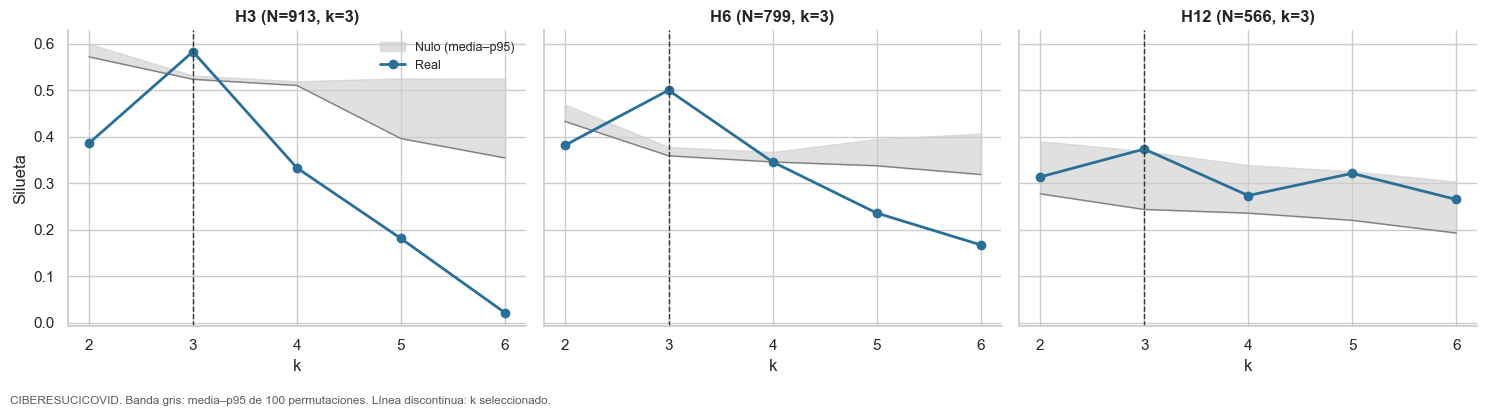

,Horizonte,k,silueta_real,nulo_media,nulo_p95,Ventaja frente al nulo,supera_p95,Elegido
0,H3,2,0.386,0.572,0.600,-0.186,False,False
1,H3,3,0.583,0.523,0.532,0.059,True,True
2,H3,4,0.333,0.510,0.519,-0.177,False,False
3,H3,5,0.181,0.396,0.525,-0.215,False,False
4,H3,6,0.021,0.354,0.524,-0.333,False,False
5,H6,2,0.381,0.433,0.469,-0.052,False,False
6,H6,3,0.500,0.359,0.378,0.141,True,True
7,H6,4,0.346,0.346,0.367,0.000,False,False
8,H6,5,0.236,0.337,0.395,-0.102,False,False
9,H6,6,0.167,0.319,0.406,-0.151,False,False


In [6]:
fig, axes = plt.subplots(
    1, len(HORIZONTES),
    figsize=(15, 4),
    sharey=True,
    squeeze=False
)
axes = axes.ravel()

tablas_k = []

for ax, h in zip(axes, HORIZONTES):
    r = resultados[h]
    nl = r["nulo"].sort_values("k").copy()

    x = nl["k"].to_numpy(dtype=float)
    media = nl["nulo_media"].to_numpy(dtype=float)
    p95 = nl["nulo_p95"].to_numpy(dtype=float)
    real = nl["silueta_real"].to_numpy(dtype=float)

    ax.fill_between(
        x, media, p95,
        color="0.8", alpha=0.6,
        label="Nulo (media–p95)"
    )
    ax.plot(x, media, color="0.5", lw=1)
    ax.plot(
        x, real, "o-",
        color=COLOR[DESC], lw=2,
        label="Real"
    )
    ax.axvline(r["k"], color="0.2", ls="--", lw=1)

    ax.set_title(f"{h} (N={len(r['desc'])}, k={r['k']})")
    ax.set_xticks(KS)
    ax.set_xlabel("k")

    nl["Horizonte"] = h
    nl["Ventaja frente al nulo"] = (
        nl["silueta_real"] - nl["nulo_media"]
    )
    nl["Elegido"] = nl["k"].eq(r["k"])
    tablas_k.append(nl)

axes[0].set_ylabel("Silueta")
axes[0].legend(frameon=False, fontsize=9)

nota(
    axes[0],
    f"{DESC}. Banda gris: media–p95 de "
    f"{FC['n_permutaciones']} permutaciones. "
    "Línea discontinua: k seleccionado."
)
plt.tight_layout()
guardar(fig, "03_eleccion_k")
plt.show()

comparacion_k = pd.concat(tablas_k, ignore_index=True)

display(
    comparacion_k[[
        "Horizonte", "k", "silueta_real",
        "nulo_media", "nulo_p95",
        "Ventaja frente al nulo", "supera_p95", "Elegido"
    ]].round(3)
)

comparacion_k.to_csv(TAB / "03_comparacion_k.csv", index=False)

El procedimiento selecciona tres grupos en los tres horizontes. La silueta real supera a la de los datos permutados, aunque la ventaja es pequeña: +0,06 en H3, +0,14 en H6 y +0,13 en H12.

Perfiles de los fenotipos

In [7]:
perfiles = []

for h, r in resultados.items():
    t = r["desc"][r["cols"]].copy()
    t["Fenotipo"] = [nombre_f(c) for c in r["lab"]]

    for fenotipo, grupo in t.groupby("Fenotipo", sort=True):
        n = len(grupo)

        for variable in r["cols"]:
            s = grupo[variable].dropna()
            suficiente = n >= N_MIN and len(s) >= N_MIN

            perfiles.append({
                "Horizonte": h,
                "Fenotipo": fenotipo,
                "Variable": variable,
                "N grupo": n if n >= N_MIN else np.nan,
                "N con dato": len(s) if suficiente else np.nan,
                "Mediana": s.median() if suficiente else np.nan,
                "P25": s.quantile(0.25) if suficiente else np.nan,
                "P75": s.quantile(0.75) if suficiente else np.nan,
                "Cobertura (%)": (
                    100 * len(s) / n if suficiente else np.nan
                ),
            })

perfiles = pd.DataFrame(perfiles)

for h in HORIZONTES:
    print(f"\n{h}: medianas por fenotipo")
    display(
        perfiles.loc[perfiles["Horizonte"].eq(h)]
        .pivot(index="Variable", columns="Fenotipo", values="Mediana")
        .round(2)
    )

perfiles.to_csv(TAB / "03_perfiles_clinicos.csv", index=False)


H3: medianas por fenotipo


Fenotipo,F1,F2,F3
Variable,,,
dlco_M3,79.2,69.65,67.0
fatiga_M3,0.0,1.00,0.0
fvc_M3,93.0,85.60,84.0
resolucion_M3,0.0,1.00,1.0



H6: medianas por fenotipo


Fenotipo,F1,F2,F3
Variable,,,
dlco_M3,67.00,65.0,63.0
dlco_M6,78.00,71.0,70.0
dlco_cambio,5.90,4.5,4.5
fatiga_M3,0.00,1.0,0.0
fatiga_M6,0.00,1.0,0.0
fvc_M3,91.15,82.0,84.0
fvc_M6,93.00,88.0,87.0
fvc_cambio,3.00,6.0,5.8
resolucion_M3,1.00,1.0,1.0



H12: medianas por fenotipo


Fenotipo,F1,F2,F3
Variable,,,
dlco_A1,78.0,76.0,74.0
dlco_M3,69.0,67.0,65.0
dlco_M6,71.5,68.0,67.0
dlco_cambio,8.0,2.1,6.0
fatiga_M3,0.0,1.0,0.0
fatiga_M6,0.0,1.0,0.0
fvc_A1,94.0,93.0,83.0
fvc_M3,90.0,85.6,79.5
fvc_M6,91.0,87.0,85.0


F1 mantiene una función pulmonar más favorable, F2 se distingue por la fatiga y F3 por no tener fatiga pero tampoco una resolución completa, con la DLCO algo más baja. Sin embargo, esta similitud entre horizontes no demuestra que los mismos pacientes permanezcan en cada grupo.

Estabilidad y transferencia a otras cohortes


In [8]:
filas_validacion = []

for h, r in resultados.items():
    fila = {
        "Horizonte": h,
        "Jaccard bootstrap mínimo": (
            r["estab"]["jaccard_medio"].min()
        ),
        "ARI solo DLCO/FVC": r["ari_solo_compartidas"],
    }

    for cohorte, out in r["replicas"].items():
        etiqueta = ETQ.get(cohorte, cohorte)
        fila[f"ARI transferencia vs nativo: {etiqueta}"] = out["ari"]
        fila[f"IC95 inferior: {etiqueta}"] = out["ari_ic"][0]
        fila[f"IC95 superior: {etiqueta}"] = out["ari_ic"][1]

    filas_validacion.append(fila)

validacion = pd.DataFrame(filas_validacion).set_index("Horizonte")
display(validacion.round(3))
validacion.to_csv(TAB / "03_validacion_fenotipos.csv")

,Jaccard bootstrap mínimo,ARI solo DLCO/FVC,ARI transferencia vs nativo: POSTCOVID-Lleida,IC95 inferior: POSTCOVID-Lleida,IC95 superior: POSTCOVID-Lleida,ARI transferencia vs nativo: TENACITY,IC95 inferior: TENACITY,IC95 superior: TENACITY
Horizonte,,,,,,,,
H3,0.980,0.008,0.168,0.132,0.239,0.200,0.059,0.273
H6,0.998,0.004,0.239,0.051,0.304,0.293,0.047,0.386
H12,0.623,0.036,0.287,0.071,0.390,0.281,0.017,0.430


Los fenotipos presentan una elevada estabilidad interna en H3 y H6, con Jaccard mínimos de 0,980 y 0,998, pero menor estabilidad en H12, con 0,623. Su transferencia a Lleida y TENACITY muestra una concordancia limitada con los agrupamientos propios de esas cohortes, aunque los intervalos de confianza excluyen cero. Además, los ARI próximos a cero al utilizar solo DLCO y FVC indican que estas variables no bastan para recuperar los fenotipos originales: la estabilidad dentro de CIBERESUCICOVID no implica que los grupos sean directamente reproducibles en otras poblaciones.

Transiciones entre horizontes de tiempo de 3, 6 y 12 meses

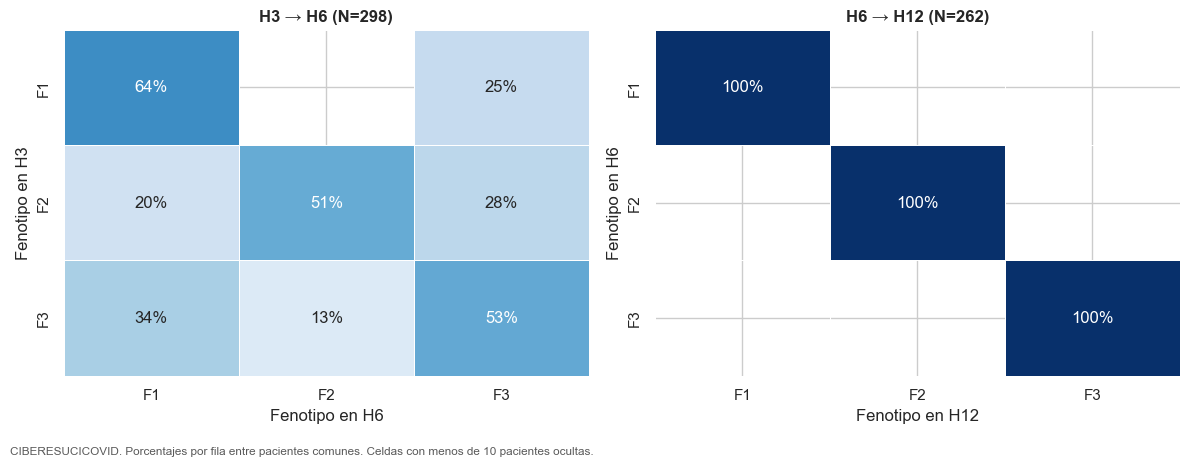

,N inicial,Pacientes comunes,% inicial con etiqueta posterior,ARI
Transición,,,,
H3 → H6,913,298,32.64,0.11
H6 → H12,799,262,32.79,1.00


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
filas = []
tablas_transicion = {}

for ax, (h1, h2) in zip(
    axes, [("H3", "H6"), ("H6", "H12")]
):
    r1, r2 = resultados[h1], resultados[h2]

    e1 = pd.Series(
        [nombre_f(c) for c in r1["lab"]],
        index=r1["desc"].index,
        name=h1
    )
    e2 = pd.Series(
        [nombre_f(c) for c in r2["lab"]],
        index=r2["desc"].index,
        name=h2
    )

    assert e1.index.is_unique and e2.index.is_unique

    tabla, ari, n = P.transiciones(e1, e2)

    filas.append({
        "Transición": f"{h1} → {h2}",
        "N inicial": len(e1),
        "Pacientes comunes": n,
        "% inicial con etiqueta posterior": (
            100 * n / len(e1) if len(e1) else np.nan
        ),
        "ARI": ari,
    })

    if n:
        tabla = tabla.reindex(
            index=[nombre_f(c) for c in range(r1["k"])],
            columns=[nombre_f(c) for c in range(r2["k"])],
            fill_value=0
        )

        denominador = tabla.sum(axis=1).replace(0, np.nan)
        pct = tabla.div(denominador, axis=0).mul(100)

        ocultar = tabla.lt(N_MIN) | pct.isna()
        anotaciones = pct.map(
            lambda v: "" if pd.isna(v) else f"{v:.0f}%"
        ).mask(ocultar, "")

        sns.heatmap(
            pct,
            mask=ocultar,
            annot=anotaciones.to_numpy(),
            fmt="",
            cmap="Blues",
            vmin=0, vmax=100,
            cbar=False,
            linewidths=0.5,
            ax=ax
        )

        tabla_publica = tabla.astype(float).mask(tabla < N_MIN)
        tablas_transicion[(h1, h2)] = tabla_publica
        tabla_publica.to_csv(
            TAB / f"03_transiciones_{h1}_{h2}_conteos.csv"
        )
    else:
        ax.text(
            0.5, 0.5, "Sin pacientes comunes",
            ha="center", va="center",
            transform=ax.transAxes
        )

    ax.set_xlabel(f"Fenotipo en {h2}")
    ax.set_ylabel(f"Fenotipo en {h1}")
    ax.set_title(f"{h1} → {h2} (N={n})")

nota(
    axes[0],
    f"{DESC}. Porcentajes por fila entre pacientes comunes. "
    f"Celdas con menos de {N_MIN} pacientes ocultas."
)
plt.tight_layout()
guardar(fig, "03_transiciones")
plt.show()

resumen_transiciones = pd.DataFrame(filas).set_index("Transición")
resumen_transiciones_publico = privacidad.suprimir_celdas(
    resumen_transiciones.round(2),
    N_MIN,
    ["N inicial", "Pacientes comunes"]
)

display(resumen_transiciones_publico)
resumen_transiciones_publico.to_csv(
    TAB / "03_resumen_transiciones.csv"
)

Entre H3 y H6, la concordancia de las agrupaciones es baja (ARI = 0,11). Entre H6 y H12 es completa (ARI = 1,00), pero no indica continuidad clínica: a los 12 meses CIBERESUCICOVID no recoge síntomas, así que H12 reutiliza los de 3 y 6 meses y la partición apenas puede cambiar. Además, cada comparación incluye solo alrededor del 33 % de los pacientes iniciales.

En conjunto, identificamos tres perfiles estables en los horizontes tempranos de CIBERESUCICOVID, pero su limitada transferencia indica que no basta con trasladar los grupos originales utilizando solo las variables respiratorias. 

Esto justifica avanzar hacia fenotipado_comun, realizando el clustering conjuntamente en CIBERESUCICOVID, POSTCOVID-Lleida y TENACITY, utilizando las variables comparables entre las tres cohortes. Así buscamos perfiles comunes desde su definición, cuya estabilidad y reproducibilidad entre cohortes deberán validarse antes de utilizarlos para predecir la evolución a largo plazo.



Diferencias entre fenotipos

Resumimos en una tabla en qué se diferencian los fenotipos de H3: las variables que los definen y las que solo los describen (ingreso, eventos, TAC y FEV1). Para cada variable damos la diferencia estandarizada (SMD) entre los dos fenotipos más separados, su magnitud y una frase de lectura. Debajo, los rasgos que distinguen a cada fenotipo del resto.

In [10]:
from src import fichas

# Tabla de diferencias entre los fenotipos de CIBERESUCICOVID en el horizonte de config.yaml (H3).
# «Define»: variables del clustering. «Describe»: ingreso y seguimiento, que no entran en el clustering.
H_FICHA = cfg["fichas"]["horizonte"]
r = resultados[H_FICHA]
ids, visitas = r["desc"].index, FC["horizontes"][H_FICHA]
fen = pd.Series([nombre_f(c) for c in r["lab"]], index=ids)

d_def, i_def = fichas.variables_definicion(r["desc"], r["cols"], cfg)
d_ing, i_ing = fichas.variables_ingreso(pacientes.set_index("subject_id").reindex(ids),
                                        FC["descripcion"]["ingreso_binarias"], cfg)
seguimiento, i_seg = {}, []
for regla, bloque, variables in [("alguna", "Describe · eventos hasta la visita", FC["descripcion"]["eventos"]),
                                 ("alguna", "Describe · TAC (solo quien lo tiene)", FC["descripcion"]["imagen"]),
                                 ("ultima", "Describe · espirometría", FC["descripcion"]["otras"])]:
    for v in variables:
        seguimiento[v] = F.estado_hasta(medidas, cfg, DESC, ids, v, visitas, regla)
        i_seg.append({"col": v, "bloque": bloque, "variable": fichas.etiqueta_estado(v, cfg), "binaria": True})

datos = pd.concat([d_def, d_ing, pd.DataFrame(seguimiento, index=ids)], axis=1)
diferencias, retratos = fichas.tabla_diferencias(datos, i_def + i_ing + i_seg, fen, cfg)
diferencias.to_csv(TAB / f"03_diferencias_fenotipos_{H_FICHA}.csv")
retratos.to_csv(TAB / f"03_retratos_fenotipos_{H_FICHA}.csv")

print(f"{ETQ[DESC]} · {H_FICHA} · N = {len(fen)}. Continuas: mediana [P25–P75]; binarias: %. "
      "SMD máx.: diferencia estandarizada entre los dos fenotipos más separados (0,2 pequeña · 0,5 moderada · 0,8 grande). "
      "«<x %»: menos de 10 casos. Las variables que definen el fenotipo no llevan p: difieren por construcción.")
display(diferencias)
display(retratos)

CIBERESUCICOVID · H3 · N = 913. Continuas: mediana [P25–P75]; binarias: %. SMD máx.: diferencia estandarizada entre los dos fenotipos más separados (0,2 pequeña · 0,5 moderada · 0,8 grande). «<x %»: menos de 10 casos. Las variables que definen el fenotipo no llevan p: difieren por construcción.


F1 (N=255)  F2 (N=362)  F3 (N=296)  N con dato SMD máx.      Magnitud  p ajustada                                              Interpretación
bloque                               variable                                                                                                                                                                          
Define el fenotipo                   DLCO M3                              79 [67–90]  70 [58–82]  67 [54–82]         743     0.55      moderada  — (define)                Más alta en F1 (79) que en F2 (70) y F3 (67)
                                     DLCO < 80 % (M3)                           50 %        71 %        72 %         743     0.46       pequeña  — (define)   Menos frecuente en F1 (50 %) que en F2 (71 %) y F3 (72 %)
                                     FVC M3                              93 [81–101]  86 [74–96]  84 [73–96]         899     0.47       pequeña  — (define)                Más alta en F1 (93) que en F2 (86) y F3 (84)
                                     FVC < 80 % (M3)                            22 %        37 %        40 %         899     0.38       pequeña  — (define)   Menos frecuente en F1 (22 %) que en F2 (37 %) y F3 (40 %)
                                     Fatiga (M3)                                 0 %       100 %         0 %         912        ∞        grande  — (define)      Más frecuente en F2 (100 %) que en F1 (0 %) y F3 (0 %)
                                     Resolución incompleta (M3)                 <4 %       100 %        98 %         913     7.00        grande  — (define)  Menos frecuente en F1 (<4 %) que en F2 (100 %) y F3 (98 %)
Describe · ingreso                   Edad ≥ 65 años                             30 %        32 %        31 %         913     0.04  despreciable       0.873                                  Sin diferencias relevantes
                                     Mujer                                      18 %        34 %        31 %         912     0.38       pequeña      <0.001   Menos frecuente en F1 (18 %) que en F2 (34 %) y F3 (31 %)
                                     Estancia hospitalaria (días)         21 [14–35]  27 [17–47]  30 [18–46]         911     0.40       pequeña      <0.001                Más baja en F1 (21) que en F2 (27) y F3 (30)
                                     Ingreso en UCI                            100 %       100 %       100 %         913     0.00  despreciable           —                                  Sin diferencias relevantes
                                     Traqueostomía                              22 %        32 %        37 %         912     0.33       pequeña       0.003   Menos frecuente en F1 (22 %) que en F2 (32 %) y F3 (37 %)
                                     Hipertensión                               41 %        46 %        44 %         913     0.10  despreciable       0.642                                  Sin diferencias relevantes
                                     Diabetes                                   16 %        18 %        11 %         913     0.18  despreciable       0.178                                  Sin diferencias relevantes
                                     EPOC                                        4 %         6 %        <3 %         913     0.14  despreciable       0.244                                  Sin diferencias relevantes
                                     Cardiopatía crónica                        12 %        10 %         9 %         913     0.07  despreciable       0.709                                  Sin diferencias relevantes
                                     Enfermedad renal crónica                   <4 %         5 %         5 %         913     0.06  despreciable       0.347                                  Sin diferencias relevantes
Describe · eventos hasta la visita   Reingreso                                   5 %         4 %        <3 %         911     0.08  despreciable       0.356                               

,Lo que lo define (frente al resto),Lo que lo acompaña (frente al resto)
Fenotipo,,
F1 (N=255),↓ Resolución incompleta (M3): <4 % vs 99 % · ↓ Fatiga (M3): 0 % vs 55 % · ↑ DLCO M3: 79 vs 68 · ↑ FVC M3: ...,↓ Estancia hospitalaria (días): 21 vs 29 · ↓ FEV1 < 80 %: 16 % vs 31 % · ↓ Mujer: 18 % vs 33 % · ↑ TAC nor...
F2 (N=362),↑ Fatiga (M3): 100 % vs 0 % · ↑ Resolución incompleta (M3): 100 % vs 53 % · ↑ DLCO < 80 % (M3): 71 % vs 62 %,↑ TAC con patrón intersticial (EPID): 11 % vs 5 % · ↑ Mujer: 34 % vs 25 %
F3 (N=296),↓ Fatiga (M3): 0 % vs 59 % · ↑ Resolución incompleta (M3): 98 % vs 59 % · ↓ DLCO M3: 67 vs 74 · ↓ FVC M3: ...,↓ TAC normalizado: 11 % vs 19 %


### 2.2 Clusterización en todos los datasets

#### 2.2.1 Inicialización

In [11]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import adjusted_rand_score

RAIZ = Path.cwd()
sys.path.insert(0, str(RAIZ))
from src import carga, fenotipado_perfil as FP, pasaporte as P, privacidad

cfg = carga.cargar_config()
PF = FP.perfil(cfg, "fenotipado_comun")
COHORTES = PF["cohortes"]
SEMILLA = cfg["semilla"]
N_MIN = cfg["privacidad"]["n_minimo_celda"]
COLOR = cfg["colores_registro"]
ETQ = {"CIBERESUCICOVID": "CIBERESUCICOVID", "POSTCOVID_LLEIDA": "POSTCOVID-Lleida", "TENACITY": "TENACITY"}
HORIZONTES = list(PF["horizontes"])
KS = list(range(PF["k_rango"][0], PF["k_rango"][1] + 1))
DATOS = carga.RAIZ / cfg["rutas"]["procesados"]
FIG = RAIZ / cfg["rutas"]["figuras"] / "main"; FIG.mkdir(parents=True, exist_ok=True)
TAB = RAIZ / cfg["rutas"]["tablas"] / "main"; TAB.mkdir(parents=True, exist_ok=True)
PFX = "04_comun"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold", "axes.titlesize": 11.5,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 220)


def nota(fig, texto: str) -> None:
    fig.text(0.01, -0.01, texto, fontsize=8.5, color="0.35", va="top", ha="left")


def guardar(fig, nombre: str) -> None:
    fig.savefig(FIG / f"{PFX}_{nombre}.png", bbox_inches="tight", dpi=150)


def ic_wilson(k: int, n: int, z: float = 1.96) -> tuple[float, float]:
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    c = (p + z**2 / (2 * n)) / (1 + z**2 / n)
    m = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
    return (100 * (c - m), 100 * (c + m))


def nombre_f(c: int) -> str:
    return f"F{c + 1}"


def pct_seguro(serie: pd.Series) -> float:
    """% de 1 en una serie 0/1 (NaN si N < N_MIN o si hay entre 1 y N_MIN−1 casos)."""
    s = serie.dropna(); k = int(s.sum())
    return 100 * k / len(s) if len(s) >= N_MIN and (k == 0 or k >= N_MIN) else np.nan


def cramer_v(tabla: pd.DataFrame) -> float:
    chi2 = stats.chi2_contingency(tabla)[0]
    return float(np.sqrt(chi2 / (tabla.values.sum() * (min(tabla.shape) - 1))))

#### 2.2.2 Carga de datos

Cargamos todos los datos necesarios para realizar el clústering.

In [12]:
pacientes = pd.read_parquet(DATOS / "pacientes.parquet")
medidas = pd.read_parquet(DATOS / "medidas.parquet")
tablas_var = {}
for h in HORIZONTES:
    partes = [FP.construir_variables(medidas, pacientes, cfg, PF, h, c) for c in COHORTES]
    tablas_var[h] = (pd.concat([t for t, _ in partes]), partes[0][1])
    limite = PF["visitas"][PF["horizontes"][h][-1]]["ventana"][1]
    assert tablas_var[h][0]["dias_max"].max() <= limite, "fuga de datos futuros"
    assert tablas_var[h][0].index.is_unique, "paciente duplicado entre cohortes"
print("Comprobado: sin datos posteriores al horizonte y sin pacientes duplicados entre cohortes.")
n_tabla = pd.DataFrame({h: tablas_var[h][0]["cohorte_analisis"].astype(str).value_counts().rename(ETQ) for h in HORIZONTES})
n_tabla.loc["Total"] = n_tabla.sum()
privacidad.suprimir_celdas(n_tabla, N_MIN, HORIZONTES)

Comprobado: sin datos posteriores al horizonte y sin pacientes duplicados entre cohortes.


,H3,H6,H12
cohorte_analisis,,,
CIBERESUCICOVID,956,860,567
POSTCOVID-Lleida,464,384,301
TENACITY,154,60,66
Total,1574,1304,934


#### 2.2.3 Clustering

A continuación realizamos el clústering. Calculamos la distancia de Gower y utilizamos el método PAM. Para seleccionar el número de *k* óptimo, primero generamos una distribución nula mediante permutaciones. Si esto no nos fuerza una *k*, utilizamos la *k* que maximiza la silueta. 

In [13]:
def ejecutar(h: str, k_forzado: int | None = None, columnas: list[str] | None = None, excluir: str | None = None,
             filtro=None, n_perm: int | None = None, n_boot: int | None = None) -> dict:
    """Clustering conjunto de un horizonte: k contra el nulo, PAM y estabilidad bootstrap."""
    t, cols = tablas_var[h]
    cols = columnas or cols
    if excluir is not None:
        t = t[t["cohorte_analisis"] != excluir]
    if filtro is not None:
        t = t[filtro(t)]
    t = t[t[cols].notna().any(axis=1)]
    X = t[cols].to_numpy(float)
    R, w, cat = FP.parametros_gower(cols, PF)
    D = FP.gower(X, None, R, w, cat)
    nulo = FP.seleccion_k_nulo(X, R, w, cat, KS, n_perm or PF["n_permutaciones"], SEMILLA, D)
    k, estructura = (k_forzado, bool(nulo.set_index("k").loc[k_forzado, "supera_p95"])) if k_forzado else FP.elegir_k(nulo)
    lab, med = FP.pam(D, k, SEMILLA)
    ultima = PF["horizontes"][h][-1]
    lab, med = FP.ordenar_por_dlco(lab, med, t[f"dlco_{ultima}"].to_numpy(float))
    return {"h": h, "cols": cols, "R": R, "w": w, "cat": cat, "desc": t, "X": X, "D": D, "nulo": nulo, "k": k,
            "estructura": estructura, "lab": lab, "med": med, "silueta": FP.silueta(D, lab),
            "estab": FP.estabilidad_bootstrap(D, lab, k, n_boot or PF["n_bootstrap"], SEMILLA)}


resultados = {h: ejecutar(h) for h in HORIZONTES}
for h, r in resultados.items():
    print(f"{h}: N = {len(r['desc'])}, k = {r['k']}, estructura frente al nulo = {'sí' if r['estructura'] else 'NO'}, "
          f"silueta = {r['silueta']:.2f} (nula {r['nulo'].set_index('k').loc[r['k'], 'nulo_media']:.2f})")

H3: N = 1574, k = 2, estructura frente al nulo = sí, silueta = 0.36 (nula 0.11)
H6: N = 1304, k = 4, estructura frente al nulo = sí, silueta = 0.17 (nula 0.03)
H12: N = 934, k = 2, estructura frente al nulo = sí, silueta = 0.29 (nula 0.05)


Gráfico para ver el índice silueta en función de *k* para cada horizonte. 

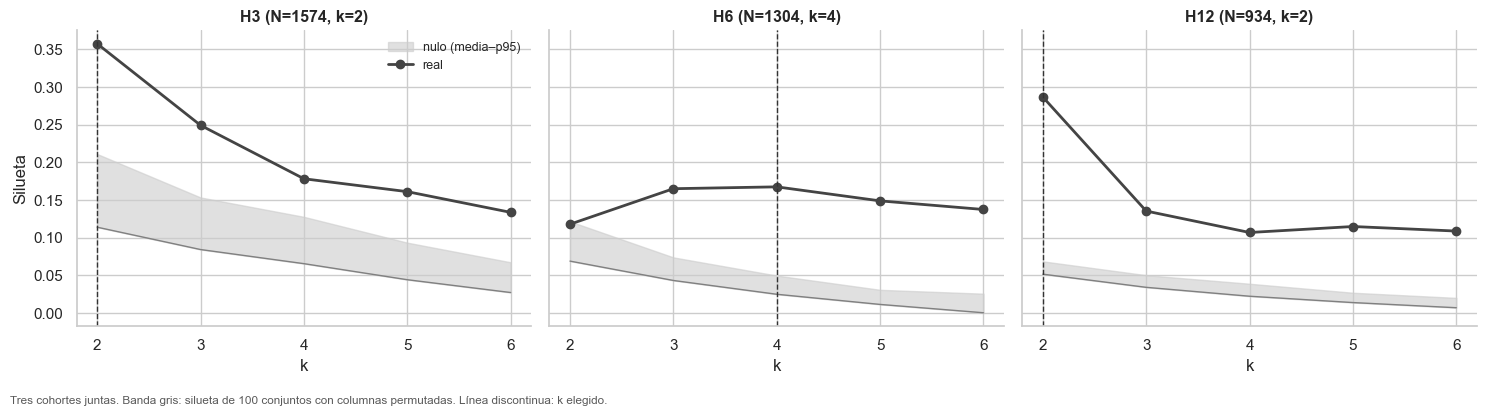

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, h in zip(axes, HORIZONTES):
    r = resultados[h]; nl = r["nulo"]
    ax.fill_between(nl["k"], nl["nulo_media"], nl["nulo_p95"], color="0.8", alpha=0.6, label="nulo (media–p95)")
    ax.plot(nl["k"], nl["nulo_media"], color="0.5", lw=1)
    ax.plot(nl["k"], nl["silueta_real"], "o-", color="#444", lw=2, label="real")
    ax.axvline(r["k"], color="0.2", ls="--", lw=1)
    ax.set_title(f"{h} (N={len(r['desc'])}, k={r['k']})"); ax.set_xticks(KS); ax.set_xlabel("k")
axes[0].set_ylabel("Silueta"); axes[0].legend(frameon=False, fontsize=9)
nota(fig, f"Tres cohortes juntas. Banda gris: silueta de {PF['n_permutaciones']} conjuntos con columnas permutadas. "
          "Línea discontinua: k elegido.")
plt.tight_layout(); guardar(fig, "eleccion_k"); plt.show()

#### 2.2.4 Perfiles de los fenotipos

Calculamos la mediana de cada variable clínica para cada fenotipo de cada horizonte.

In [15]:
filas = []
for h, r in resultados.items():
    d = r["desc"].assign(fenotipo=[nombre_f(c) for c in r["lab"]])
    ultima = PF["horizontes"][h][-1]
    for (fen, coh), g in d.groupby(["fenotipo", "cohorte_analisis"], observed=True):
        if len(g) >= N_MIN:
            filas.append({"horizonte": h, "fenotipo": fen, "cohorte": ETQ[str(coh)], "N": len(g),
                          **{f"{v}_{ultima} (mediana)": round(g[f"{v}_{ultima}"].median(), 1) for v in ["dlco", "fvc", "fev1"]}})
perfil_cohorte = pd.DataFrame(filas).set_index(["horizonte", "fenotipo", "cohorte"])
perfil_cohorte.to_csv(TAB / f"{PFX}_perfil_por_cohorte.csv")
perfil_cohorte

N  dlco_T3 (mediana)  fvc_T3 (mediana)  fev1_T3 (mediana)  dlco_T6 (mediana)  fvc_T6 (mediana)  fev1_T6 (mediana)  dlco_T12 (mediana)  fvc_T12 (mediana)  fev1_T12 (mediana)
horizonte fenotipo cohorte                                                                                                                                                                                         
H3        F1       CIBERESUCICOVID   543               78.0              97.0               99.0                NaN               NaN                NaN                 NaN                NaN                 NaN
                   POSTCOVID-Lleida  205               78.1              93.0              100.0                NaN               NaN                NaN                 NaN                NaN                 NaN
                   TENACITY           73               87.5              96.0               96.0                NaN               NaN                NaN                 NaN                NaN                 NaN
          F2       CIBERESUCICOVID   413               64.0              73.0               76.0                NaN               NaN                NaN                 NaN                NaN                 NaN
                   POSTCOVID-Lleida  259               63.8              73.0               77.7                NaN               NaN                NaN                 NaN                NaN                 NaN
                   TENACITY           81               74.0              74.0               68.0                NaN               NaN                NaN                 NaN                NaN                 NaN
H6        F1       CIBERESUCICOVID   252                NaN               NaN                NaN               87.0             100.0              106.0                 NaN                NaN                 NaN
                   POSTCOVID-Lleida   77                NaN               NaN                NaN               84.0              98.7              107.0                 NaN                NaN                 NaN
                   TENACITY           11                NaN               NaN                NaN               98.0             107.0              105.0                 NaN                NaN                 NaN
          F2       CIBERESUCICOVID   176                NaN               NaN                NaN               75.0              92.5               98.0                 NaN                NaN                 NaN
                   POSTCOVID-Lleida   98                NaN               NaN                NaN               73.6              87.0               94.7                 NaN                NaN                 NaN
                   TENACITY           15                NaN               NaN                NaN               72.0              89.0               80.0                 NaN                NaN                 NaN
          F3       CIBERESUCICOVID   290                NaN               NaN                NaN               68.0              85.0               90.0                 NaN                NaN                 NaN
                   POSTCOVID-Lleida  126                NaN               NaN                NaN               69.0              84.0               90.0                 NaN                NaN                 NaN
                   TENACITY           15                NaN               NaN                NaN               86.0              87.0               88.0                 NaN                NaN                 NaN
          F4       CIBERESUCICOVID   142                NaN               NaN                NaN               59.0              69.0               71.0                 NaN                NaN                 NaN
                   POSTCOVID-Lleida   83                NaN               NaN                NaN               58.0              67.0               70.0                 NaN                NaN                 NaN
           

Calculamos el Jaccard medio para cada fenotipo y damos un veredicto: si es <0.5 se disuelve, si está entre 0,5-0,75 tiene un patrón, con una estabilidad moderada. Y si se encuentra en el rango ≥ 0,75, decimos que es un clúster estable.

In [16]:
filas = []
for h, r in resultados.items():
    for _, e in r["estab"].iterrows():
        filas.append({"horizonte": h, "fenotipo": nombre_f(int(e["cluster"])), "N": int(e["n"]),
                      "Jaccard medio": round(e["jaccard_medio"], 2), "Jaccard p05": round(e["jaccard_p05"], 2)})
estab = pd.DataFrame(filas)
estab["veredicto"] = pd.cut(estab["Jaccard medio"], [0, 0.5, 0.75, 1.01], labels=["se disuelve", "patrón", "estable"])
estab.to_csv(TAB / f"{PFX}_estabilidad.csv", index=False)
privacidad.suprimir_celdas(estab.set_index(["horizonte", "fenotipo"]), N_MIN, ["N"])

N  Jaccard medio  Jaccard p05 veredicto
horizonte fenotipo                                           
H3        F1        821           0.92         0.49   estable
          F2        753           0.92         0.48   estable
H6        F1        340           0.81         0.57   estable
          F2        289           0.57         0.18    patrón
          F3        431           0.77         0.47   estable
          F4        244           0.74         0.47    patrón
H12       F1        516           0.89         0.75   estable
          F2        418           0.89         0.71   estable

#### 2.2.5 Replicabilidad

Empleamos validación cruzada para evaluar la replicabilidad externa de los fenotipos mediante una estrategia de dejar una cohorte fuera. En cada iteración se excluye una cohorte completa, se ajusta el modelo PAM con los datos restantes y se transfieren los medoides a la cohorte apartada. La concordancia entre la clasificación transferida y la nativa se evalúa mediante el Índice Rand Ajustado (ARI) con un intervalo de confianza del 95 %. Si los fenotipos se reproducen en la cohorte apartada, no dependen de la cohorte con la que se descubrieron.

In [17]:
filas = []
loco = {}
for h, r in resultados.items():
    t = r["desc"]
    for c in COHORTES:
        dentro = (t["cohorte_analisis"] == c).values
        if dentro.sum() < 2 * r["k"]:
            continue
        X_otros, X_c = r["X"][~dentro], r["X"][dentro]
        D_otros = r["D"][np.ix_(~dentro, ~dentro)]
        lab_o, med_o = FP.pam(D_otros, r["k"], SEMILLA)
        lab_o, med_o = FP.ordenar_por_dlco(lab_o, med_o, t.loc[~dentro, f"dlco_{PF['horizontes'][h][-1]}"].to_numpy(float))
        out = P.replicar(X_otros, med_o, X_c, r["R"], r["w"], r["cat"], r["k"], PF["n_bootstrap"], SEMILLA)
        loco[(h, c)] = out
        filas.append({"horizonte": h, "cohorte excluida": ETQ[c], "N": int(dentro.sum()), "k": r["k"],
                      "ARI transferidas frente a nativas": round(out["ari"], 2),
                      "IC95": f"{out['ari_ic'][0]:.2f} a {out['ari_ic'][1]:.2f}",
                      "ARI frente al clustering conjunto": round(adjusted_rand_score(r["lab"][dentro], out["transferidas"]), 2),
                      "Jaccard por fenotipo": " / ".join(f"{j:.2f}" for j in out["jaccard"])})
validacion = pd.DataFrame(filas).set_index(["horizonte", "cohorte excluida"])
validacion.to_csv(TAB / f"{PFX}_validacion_loco.csv")
validacion

N  k  ARI transferidas frente a nativas          IC95  ARI frente al clustering conjunto       Jaccard por fenotipo
horizonte cohorte excluida                                                                                                                       
H3        CIBERESUCICOVID   956  2                               0.50   0.26 a 0.62                               0.56                0.79 / 0.68
          POSTCOVID-Lleida  464  2                               0.61   0.26 a 0.81                               0.95                0.80 / 0.81
          TENACITY          154  2                               0.73   0.18 a 0.87                               1.00                0.87 / 0.87
H6        CIBERESUCICOVID   860  4                               0.30   0.25 a 0.48                               0.27  0.40 / 0.51 / 0.54 / 0.03
          POSTCOVID-Lleida  384  4                               0.30   0.23 a 0.44                               0.89  0.33 / 0.05 / 0.52 / 0.54
          TENACITY           60  4                               0.27   0.07 a 0.37                               1.00  0.73 / 0.27 / 0.41 / 0.50
H12       CIBERESUCICOVID   567  2                               0.34   0.20 a 0.45                               0.37                0.69 / 0.61
          POSTCOVID-Lleida  301  2                               0.21   0.04 a 0.70                               1.00                0.60 / 0.54
          TENACITY           66  2                               0.05  -0.06 a 0.63                               0.77                0.45 / 0.48

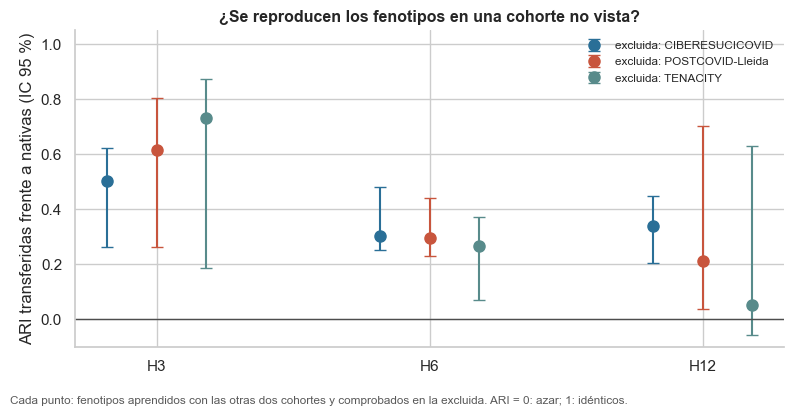

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
for i, c in enumerate(COHORTES):
    xs, ys, lo, hi = [], [], [], []
    for j, h in enumerate(HORIZONTES):
        out = loco.get((h, c))
        if out is None:
            continue
        xs.append(j + (i - 1) * 0.18); ys.append(out["ari"])
        lo.append(out["ari"] - out["ari_ic"][0]); hi.append(out["ari_ic"][1] - out["ari"])
    ax.errorbar(xs, ys, yerr=[lo, hi], fmt="o", ms=8, capsize=4, color=COLOR[c], label=f"excluida: {ETQ[c]}")
ax.axhline(0, color="0.3", lw=1); ax.set_xticks(range(len(HORIZONTES)), HORIZONTES); ax.set_ylim(-0.1, 1.05)
ax.set_ylabel("ARI transferidas frente a nativas (IC 95 %)"); ax.set_title("¿Se reproducen los fenotipos en una cohorte no vista?")
ax.legend(frameon=False, fontsize=8.5)
nota(fig, "Cada punto: fenotipos aprendidos con las otras dos cohortes y comprobados en la excluida. ARI = 0: azar; 1: idénticos.")
plt.tight_layout(); guardar(fig, "validacion_loco"); plt.show()

#### 2.2.6 Reconocer el fenotipo con pocas variables

Para que el fenotipo se pueda usar en la consulta, comprobamos si se reconoce con una regla sencilla. Entrenamos un árbol de decisión muy corto (de 1 y 2 preguntas) con la DLCO, la FVC y el FEV1 a los 3 meses, y lo validamos dejando fuera cada cohorte.

In [19]:
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score, average_precision_score

r = resultados["H3"]
X = r["desc"][["dlco_T3", "fvc_T3", "fev1_T3"]]
y = (r["lab"] == 1).astype(int)                      # 1 = F2 (afectación funcional)
coh = r["desc"]["cohorte_analisis"].astype(str).values

filas = []
for prof in [1, 2]:
    for c in COHORTES:
        fuera = coh == c
        arbol = DecisionTreeClassifier(max_depth=prof, min_samples_leaf=N_MIN, random_state=SEMILLA).fit(X[~fuera], y[~fuera])
        p = arbol.predict_proba(X[fuera])[:, 1]
        filas.append({"profundidad": prof, "cohorte excluida": ETQ[c], "N": int(fuera.sum()),
                      "acierto": round(accuracy_score(y[fuera], p >= 0.5), 3),
                      "AUC-PR": round(average_precision_score(y[fuera], p), 3),
                      "observado − predicho (pp)": round(100 * (y[fuera].mean() - p.mean()), 1)})
sello4 = pd.DataFrame(filas).set_index(["profundidad", "cohorte excluida"])
sello4.to_csv(TAB / f"{PFX}_sello4_clasificador.csv")

regla = DecisionTreeClassifier(max_depth=1, min_samples_leaf=N_MIN, random_state=SEMILLA).fit(X, y)
print(export_text(regla, feature_names=["DLCO a 3 m", "FVC a 3 m", "FEV1 a 3 m"], class_names=["F1", "F2"]))
sello4

|--- FVC a 3 m <= 82.85
|   |--- class: F2
|--- FVC a 3 m >  82.85
|   |--- class: F1



N  acierto  AUC-PR  observado − predicho (pp)
profundidad cohorte excluida                                                 
1           CIBERESUCICOVID   956    0.949   0.924                        0.4
            POSTCOVID-Lleida  464    0.953   0.933                       -0.9
            TENACITY          154    0.968   0.958                        1.5
2           CIBERESUCICOVID   956    0.932   0.962                       -0.2
            POSTCOVID-Lleida  464    0.957   0.969                        1.1
            TENACITY          154    0.961   0.968                       -0.4

Con una sola pregunta, **¿FVC a los 3 meses ≤ 83 %?**, acertamos el fenotipo en el 95–97 % de los pacientes de una cohorte que el árbol no ha visto, y la proporción de F2 predicha coincide con la observada (menos de 2 puntos de diferencia). Con dos preguntas el acierto no mejora (el AUC-PR sube algo, de 0,92–0,96 a 0,96–0,97), así que nos quedamos con la regla de una sola pregunta. El clustering ha encontrado por sí solo un corte muy cercano al umbral clínico del 80 %.

Guardamos los fenotipos de cada paciente, que usaremos en las trayectorias y en la predicción.

In [20]:
filas = []
for h, r in resultados.items():
    D_med = FP.gower(r["X"], r["X"][r["med"]], r["R"], r["w"], r["cat"])
    filas.append(pd.DataFrame({"subject_id": r["desc"].index, "horizonte": h,
                               "cohorte_analisis": r["desc"]["cohorte_analisis"].astype(str).values,
                               "fenotipo": [nombre_f(c) for c in r["lab"]],
                               "distancia_medoide": D_med[np.arange(len(r["lab"])), r["lab"]]}))
fenotipos = pd.concat(filas, ignore_index=True)
fenotipos.to_parquet(DATOS / "fenotipos_comun.parquet", index=False)

base = fenotipos.pivot(index="subject_id", columns="horizonte", values="fenotipo").add_prefix("fenotipo_")
pred = pacientes.set_index("subject_id")[["cohorte_analisis", "centro_id", *PF["predictores_alta"]]]
base = pred.join(base, how="inner")
for nombre, v, visitas, regla in PF["desenlaces"]:
    col = "y_" + nombre.split(" ")[0].lower().replace("-", "_")
    partes = [FP.estado_hasta(medidas, cfg, PF, c, base.index[base["cohorte_analisis"] == c], v, visitas, regla)
              for c in COHORTES if FP.visitas_que_recogen(cfg, PF, v, c) & set(visitas)]
    base[col] = pd.concat(partes).reindex(base.index) if partes else np.nan
base.reset_index().to_parquet(DATOS / "base_modelo.parquet", index=False)
print(f"Guardado {DATOS.name}/fenotipos_comun.parquet ({len(fenotipos):,} filas) y "
      f"{DATOS.name}/base_modelo.parquet ({len(base):,} pacientes × {base.shape[1]} columnas)")

disp = base.groupby("cohorte_analisis", observed=True).apply(lambda d: d.notna().mean() * 100, include_groups=False).round(0).T
disp.columns = [ETQ[str(c)] for c in disp.columns]
disp.loc["N pacientes"] = base["cohorte_analisis"].astype(str).value_counts().rename(ETQ)
print("% de pacientes con dato en cada columna de la tabla base:")
disp

Guardado Datos limpios/fenotipos_comun.parquet (3,812 filas) y Datos limpios/base_modelo.parquet (2,439 pacientes × 19 columnas)
% de pacientes con dato en cada columna de la tabla base:


,CIBERESUCICOVID,POSTCOVID-Lleida,TENACITY
centro_id,83.0,90.0,57.0
grupo_edad,100.0,98.0,86.0
sexo,100.0,97.0,87.0
estancia_hosp_dias,100.0,96.0,100.0
nu_ingreso_uci,100.0,100.0,100.0
nu_hta,100.0,96.0,100.0
nu_diabetes,100.0,96.0,100.0
nu_card_cronica,100.0,96.0,100.0
nu_epoc,100.0,96.0,100.0
nu_renal_cronica,100.0,96.0,100.0


El horizonte H3 es el único que pasa todas las pruebas: dos fenotipos, F1 «función conservada» (821 pacientes) y F2 «afectación funcional» (753), estables (Jaccard 0,92) y que se reproducen al dejar fuera cada cohorte (ARI 0,50–0,73). En H6 y H12 la replicación es peor (ARI entre 0,05 y 0,34), así que a partir de aquí usamos los fenotipos de H3.

#### 2.2.7 Diferencias entre fenotipos

Misma tabla para los fenotipos comunes de H3. Cada cohorte describe con lo que recoge (la columna *Cohortes con dato* dice cuáles aportan a cada fila) y lo que no recoge queda vacío, no se imputa.

In [21]:
from src import fichas

# Tabla de diferencias entre los fenotipos comunes en el horizonte de config.yaml (H3), las tres cohortes juntas.
# Cada cohorte describe con lo que recoge: lo que no recoge queda vacío (no se imputa).
H_FICHA = cfg["fichas"]["horizonte"]
r = resultados[H_FICHA]
ids, visitas = r["desc"].index, PF["horizontes"][H_FICHA]
coh = r["desc"]["cohorte_analisis"].astype(str)
fen = pd.Series([nombre_f(c) for c in r["lab"]], index=ids)
CORTO = {"CIBERESUCICOVID": "CIBERES", "POSTCOVID_LLEIDA": "Lleida", "TENACITY": "TENACITY"}

d_def, i_def = fichas.variables_definicion(r["desc"], r["cols"], cfg)
d_ing, i_ing = fichas.variables_ingreso(pacientes.set_index("subject_id").reindex(ids),
                                        PF["descripcion"]["ingreso_binarias"], cfg)
seguimiento, i_seg = {}, []
for regla in ["alguna", "ultima"]:
    for v in PF["descripcion"][regla]:
        if v in FP.variables_definicion(PF):
            continue
        seguimiento[v] = pd.concat([FP.estado_hasta(medidas, cfg, PF, c, ids[coh == c], v, visitas, regla)
                                    for c in COHORTES]).reindex(ids)
        bloque = ("Describe · TAC (solo quien lo tiene)" if v.startswith(("tac_", "tractos", "fibrosis"))
                  else "Describe · eventos hasta la visita" if regla == "alguna" else "Describe · síntomas y esfuerzo")
        i_seg.append({"col": v, "bloque": bloque, "variable": fichas.etiqueta_estado(v, cfg), "binaria": True})
for c in COHORTES:
    seguimiento[f"coh_{c}"] = (coh == c).astype(float)
    i_seg.append({"col": f"coh_{c}", "bloque": "Describe · cohorte de origen", "variable": ETQ[c], "binaria": True})

datos = pd.concat([d_def, d_ing, pd.DataFrame(seguimiento, index=ids)], axis=1)
diferencias, retratos = fichas.tabla_diferencias(datos, i_def + i_ing + i_seg, fen, cfg, coh, CORTO)
diferencias.to_csv(TAB / f"{PFX}_diferencias_fenotipos_{H_FICHA}.csv")
retratos.to_csv(TAB / f"{PFX}_retratos_fenotipos_{H_FICHA}.csv")

print(f"Tres cohortes juntas · {H_FICHA} · N = {len(fen)}. Continuas: mediana [P25–P75]; binarias: %. "
      "SMD máx.: diferencia estandarizada entre fenotipos (0,2 pequeña · 0,5 moderada · 0,8 grande). "
      "«<x %»: menos de 10 casos. Las variables que definen el fenotipo no llevan p: difieren por construcción.")
display(diferencias)
display(retratos)

Tres cohortes juntas · H3 · N = 1574. Continuas: mediana [P25–P75]; binarias: %. SMD máx.: diferencia estandarizada entre fenotipos (0,2 pequeña · 0,5 moderada · 0,8 grande). «<x %»: menos de 10 casos. Las variables que definen el fenotipo no llevan p: difieren por construcción.


F1 (N=821)  F2 (N=753)  N con dato          Cohortes con dato SMD máx.      Magnitud  p ajustada  \
bloque                               variable                                                                                                                                       
Define el fenotipo                   DLCO T3                                     79 [67–90]  65 [54–77]        1369  CIBERES, Lleida, TENACITY     0.78      moderada  — (define)   
                                     DLCO < 80 % (T3)                                  52 %        80 %        1369  CIBERES, Lleida, TENACITY     0.60      moderada  — (define)   
                                     FVC T3                                     96 [89–104]  73 [66–79]        1557  CIBERES, Lleida, TENACITY     2.56        grande  — (define)   
                                     FVC < 80 % (T3)                                    0 %        79 %        1557  CIBERES, Lleida, TENACITY     2.78        grande  — (define)   
                                     FEV1 T3                                    99 [93–107]  76 [66–83]        1553  CIBERES, Lleida, TENACITY     2.19        grande  — (define)   
                                     FEV1 < 80 % (T3)                                   2 %        62 %        1553  CIBERES, Lleida, TENACITY     1.71        grande  — (define)   
Describe · ingreso                   Edad ≥ 65 años                                    33 %        31 %        1549  CIBERES, Lleida, TENACITY     0.04  despreciable       0.600   
                                     Mujer                                             34 %        26 %        1546  CIBERES, Lleida, TENACITY     0.18  despreciable       0.001   
                                     Estancia hospitalaria (días)                21 [13–34]  26 [15–45]        1556  CIBERES, Lleida, TENACITY     0.31       pequeña      <0.001   
                                     Ingreso en UCI                                    95 %        92 %        1573  CIBERES, Lleida, TENACITY     0.13  despreciable       0.027   
                                     Traqueostomía                                     22 %        33 %        1374  CIBERES, Lleida, TENACITY     0.25       pequeña      <0.001   
                                     Hipertensión                                      40 %        49 %        1559  CIBERES, Lleida, TENACITY     0.20  despreciable      <0.001   
                                     Diabetes                                          15 %        22 %        1558  CIBERES, Lleida, TENACITY     0.19  despreciable       0.001   
                                     EPOC                                               4 %         9 %        1558  CIBERES, Lleida, TENACITY     0.21       pequeña      <0.001   
                                     Cardiopatía crónica                                9 %        11 %        1558  CIBERES, Lleida, TENACITY     0.06  despreciable       0.446   
                                     Enfermedad renal crónica                           3 %         6 %        1559  CIBERES, Lleida, TENACITY     0.18  despreciable       0.002   
Describe · eventos hasta la visita   Reingreso                                          3 %         4 %         943                    CIBERES     0.06  despreciable       0.600   
                                     Visita a urgencias                                15 %        17 %         943                    CIBERES     0.04  despreciable       0.666   
                                     Complicación cardiovascular                        3 %         3 %         944                    CIBERES     0.00  despreciable       1.000   
                                     Complicación infecciosa                            3 %         4 %         944                    CIBERES     0.08  despreciable       0.472   
Describe · TAC (solo quien lo tiene) TAC normalizado                                   20 %        

,Lo que lo define (frente al resto),Lo que lo acompaña (frente al resto)
Fenotipo,,
F1 (N=821),↓ FVC < 80 % (T3): 0 % vs 79 % · ↑ FEV1 T3: 99 vs 76 · ↑ DLCO T3: 79 vs 65,↓ TAC con lesiones fibróticas o reticulares: 54 % vs 76 % · ↓ TAC con lesiones fibróticas: 12 % vs 27 % · ...
F2 (N=753),↑ FVC < 80 % (T3): 79 % vs 0 % · ↓ FEV1 T3: 76 vs 99 · ↓ DLCO T3: 65 vs 79,↑ TAC con lesiones fibróticas o reticulares: 76 % vs 54 % · ↑ TAC con lesiones fibróticas: 27 % vs 12 % · ...


## 3. Trayectorias

Una vez tenemos los fenotipos, debemos analizar cómo evoluciona cada uno de ellos a lo largo del tiempo. Usaremos los fenotipos obtenidos clusterizando todas las cohortes juntas, por 2 motivos principales:
1. A los 3 meses es estable (Jaccard 0,92), no separa cohortes (V de Cramér 0,12, notebook 04) y se reproduce dejando fuera cada cohorte (ARI 0,50–0,73).
2. F1 y F2 significan lo mismo en CIBERESUCICOVID, Lleida y TENACITY (mismas variables, mismos rangos, mismos pesos).



### 3.1 Inicialización

In [22]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
from IPython.display import display
from scipy import stats
from sklearn.metrics import adjusted_rand_score

RAIZ = Path.cwd()
sys.path.insert(0, str(RAIZ))
from src import carga, fenotipado_perfil as FP, privacidad, trayectorias as T

warnings.filterwarnings("ignore")              # avisos de convergencia de statsmodels: se comprueba `converged`

cfg = carga.cargar_config()
TR = cfg["trayectorias"]
PFC = FP.perfil(cfg, "fenotipado_comun")       # visitas, ventanas y Gower del notebook 05
COH = TR["cohortes"]
SEMILLA = cfg["semilla"]
N_MIN = cfg["privacidad"]["n_minimo_celda"]
DPM = cfg["limpieza"]["dias_por_mes"]
MREF = TR["mes_referencia"]
TRAMOS = TR["etiquetas_tramos"]
FEN = ["F1", "F2"]
NOMF = TR["nombres"]
C_FEN = {"F1": "#1b9e77", "F2": "#d95f02"}
ETQ = {"CIBERESUCICOVID": "CIBERESUCICOVID", "POSTCOVID_LLEIDA": "POSTCOVID-Lleida", "TENACITY": "TENACITY"}
U_DLCO = cfg["umbrales_clinicos"]["dlco_pct"]
DATOS = carga.RAIZ / cfg["rutas"]["procesados"]
FIG = RAIZ / cfg["rutas"]["figuras"] / "main"; FIG.mkdir(parents=True, exist_ok=True)
TAB = RAIZ / cfg["rutas"]["tablas"] / "main"; TAB.mkdir(parents=True, exist_ok=True)
PFX = "05_tray"
FORMULA = "valor ~ fenotipo * lt + cohorte"    # conjunto: la cohorte ajusta el nivel (TENACITY tiene la DLCO más alta)
FORMULA_C = "valor ~ fenotipo * lt"            # dentro de cada cohorte

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold", "axes.titlesize": 11.5,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 200)


def nota(fig, texto: str) -> None:
    """Pie de figura con N y cohortes."""
    fig.text(0.01, -0.01, texto, fontsize=8.5, color="0.35", va="top", ha="left")


def guardar(fig, nombre: str) -> None:
    fig.savefig(FIG / f"{PFX}_{nombre}.png", bbox_inches="tight", dpi=150)


def edad_aproximada(tramo) -> float:
    """Punto medio del tramo de edad (misma regla que los notebooks de modelos)."""
    if not isinstance(tramo, str) or tramo.startswith("<"):
        return np.nan
    if tramo.endswith("+"):
        return float(tramo[:-1]) + 2
    lo, hi = tramo.split("-")
    return (float(lo) + float(hi)) / 2


def media_ic(s: pd.Series) -> tuple[float, float, float]:
    """Media e IC 95 % (t de Student)."""
    s = s.dropna(); n = len(s)
    if n < 2:
        return s.mean(), np.nan, np.nan
    h = stats.t.ppf(0.975, n - 1) * s.std(ddof=1) / np.sqrt(n)
    return s.mean(), s.mean() - h, s.mean() + h


def fmt_ic(d: dict, dec: int = 1) -> str:
    return f"{d['estimacion']:+.{dec}f} [{d['ic_inf']:+.{dec}f} a {d['ic_sup']:+.{dec}f}]"

### 3.2 Datos

Contamos cuántos pacientes tienen DLCO en cada momento (3, 6 y 12 meses).

In [23]:
pacientes = pd.read_parquet(DATOS / "pacientes.parquet")
medidas = pd.read_parquet(DATOS / "medidas.parquet")
visitas_ten = pd.read_parquet(DATOS / "visitas_tenacity.parquet")
fen = pd.read_parquet(DATOS / TR["fenotipos"])
fen = fen[(fen["horizonte"] == TR["horizonte"]) & fen["cohorte_analisis"].isin(COH)].set_index("subject_id")
fenotipo, cohorte = fen["fenotipo"].astype(str), fen["cohorte_analisis"].astype(str)

L = T.tabla_larga(medidas, fenotipo, cohorte, TR["variable"], TR["ventana_comun_dias"], DPM, MREF)
L["tramo"] = T.tramo(L["dias"], TR["tramos_dias"], TRAMOS)
# Una cifra por paciente y tramo (media si hay dos medidas en el mismo tramo): para describir, no para modelar
PT = L.groupby(["subject_id", "cohorte", "fenotipo", "tramo"], observed=True).agg(
    valor=("valor", "mean"), meses=("meses", "mean")).reset_index()

n_por_paciente = L.groupby("subject_id").size()
filas = []
for c in COH:
    ids = fen.index[cohorte == c]
    n = n_por_paciente.reindex(ids).fillna(0)
    filas.append({"cohorte": ETQ[c], "pacientes H3": len(ids), "con ≥ 1 DLCO": int((n >= 1).sum()),
                  "con ≥ 2 DLCO (trayectoria)": int((n >= 2).sum()), "medidas de DLCO": int(n.sum())})
datos_resumen = pd.DataFrame(filas).set_index("cohorte")
datos_resumen.loc["Total"] = datos_resumen.sum()
datos_resumen.to_csv(TAB / f"{PFX}_datos.csv")
display(privacidad.suprimir_celdas(datos_resumen, N_MIN))

n_punto = PT.groupby(["cohorte", "fenotipo", "tramo"], observed=True).size().unstack("tramo").reindex(columns=TRAMOS)
n_punto.index = [f"{ETQ[c]} · {f}" for c, f in n_punto.index]
n_punto.loc["Las tres · F1"] = PT[PT["fenotipo"] == "F1"].groupby("tramo", observed=True).size()
n_punto.loc["Las tres · F2"] = PT[PT["fenotipo"] == "F2"].groupby("tramo", observed=True).size()
n_punto = n_punto.fillna(0).astype(int)
n_punto.to_csv(TAB / f"{PFX}_n_por_punto.csv")
print("Pacientes con DLCO en cada punto temporal:")
privacidad.suprimir_celdas(n_punto, N_MIN)

,pacientes H3,con ≥ 1 DLCO,con ≥ 2 DLCO (trayectoria),medidas de DLCO
cohorte,,,,
CIBERESUCICOVID,956,822,382,1318
POSTCOVID-Lleida,464,456,307,946
TENACITY,154,151,74,248
Total,1574,1429,763,2512


Pacientes con DLCO en cada punto temporal:


tramo,T3,T6,T12
CIBERESUCICOVID · F1,447,142,120
CIBERESUCICOVID · F2,329,123,91
POSTCOVID-Lleida · F1,203,105,87
POSTCOVID-Lleida · F2,248,162,138
TENACITY · F1,72,15,20
TENACITY · F2,79,30,31
Las tres · F1,722,262,227
Las tres · F2,656,315,260


### 3.3 Evolución de la DLCO

Ajustamos un modelo mixto, DLCO ~ fenotipo × log(tiempo), con un intercepto y una pendiente para cada paciente, y lo comparamos con las medias observadas.

Modelo conjunto: 2512 medidas de 1429 pacientes; intercepto y pendiente aleatorios; convergió: True
  CIBERESUCICOVID: 1318 medidas; intercepto y pendiente aleatorios; convergió: True
  POSTCOVID-Lleida: 946 medidas; intercepto y pendiente aleatorios; convergió: True
  TENACITY: 248 medidas; intercepto y pendiente aleatorios; convergió: True


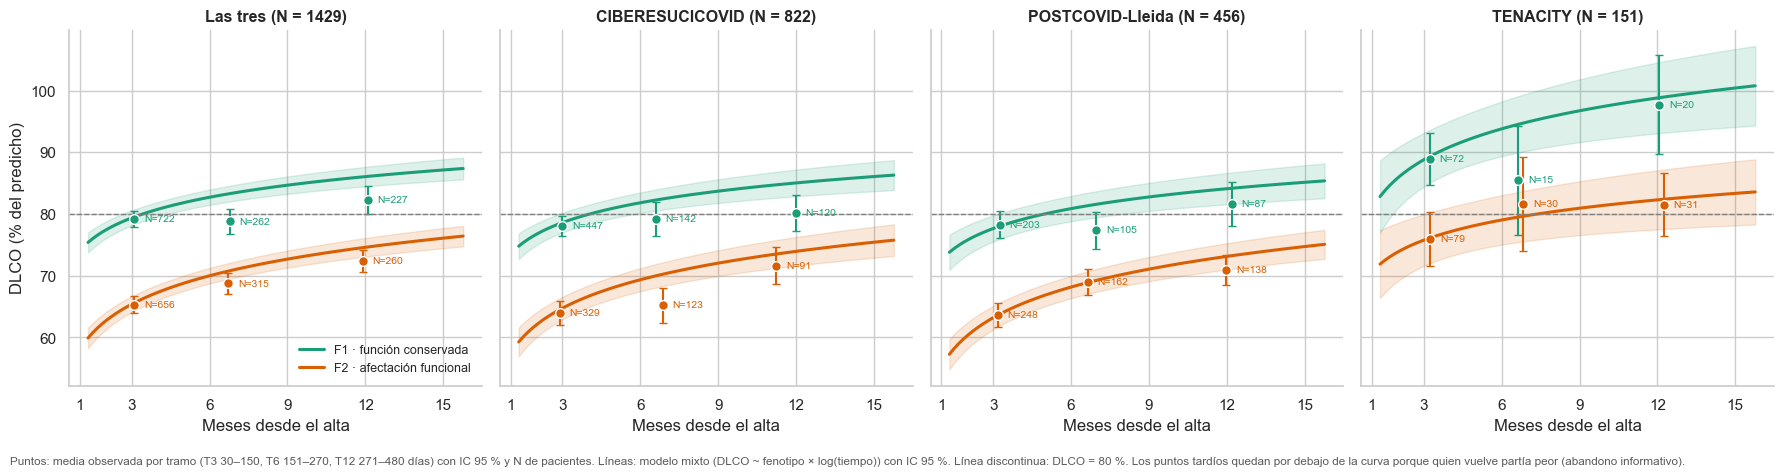

In [24]:
pesos_coh = cohorte.loc[L["subject_id"].unique()].value_counts(normalize=True).to_dict()
mixto, tipo_mixto = T.ajustar_mixto(L, FORMULA, TR["efectos_aleatorios"])
por_coh = {c: T.ajustar_mixto(L[L["cohorte"] == c], FORMULA_C, TR["efectos_aleatorios"]) for c in COH}
print(f"Modelo conjunto: {len(L)} medidas de {L['subject_id'].nunique()} pacientes; {tipo_mixto}; convergió: {mixto.converged}")
for c, (r, tipo) in por_coh.items():
    print(f"  {ETQ[c]}: {int(r.nobs)} medidas; {tipo}; convergió: {r.converged}")

rejilla = np.linspace(np.percentile(L["meses"], 2), TR["ventana_comun_dias"][1] / DPM, 80)   # sin extrapolar hacia el alta


def panel(ax, datos_pt: pd.DataFrame, res, pesos, titulo: str) -> None:
    """Medias observadas por tramo (con N) y curva del modelo con IC por fenotipo."""
    for f in FEN:
        pr = T.predicciones(res, [f], list(rejilla), MREF, pesos)
        ax.plot(rejilla, pr["estimacion"], color=C_FEN[f], lw=2.2, label=NOMF[f])
        ax.fill_between(rejilla, pr["ic_inf"], pr["ic_sup"], color=C_FEN[f], alpha=0.15)
        for t in TRAMOS:
            s = datos_pt[(datos_pt["fenotipo"] == f) & (datos_pt["tramo"] == t)]
            if len(s) < N_MIN:
                continue
            m, lo, hi = media_ic(s["valor"])
            x = s["meses"].median()
            ax.errorbar(x, m, yerr=[[m - lo], [hi - m]], fmt="o", color=C_FEN[f], mec="white", ms=7, capsize=3)
            ax.annotate(f"N={len(s)}", (x, m), textcoords="offset points", xytext=(7, 0),
                        ha="left", va="center", fontsize=7.5, color=C_FEN[f])
    ax.axhline(U_DLCO, color="0.5", ls="--", lw=1)
    ax.set_title(titulo); ax.set_xlabel("Meses desde el alta"); ax.set_xticks([1, 3, 6, 9, 12, 15])


fig, axes = plt.subplots(1, 4, figsize=(18, 4.6), sharey=True)
panel(axes[0], PT, mixto, pesos_coh, f"Las tres (N = {L['subject_id'].nunique()})")
for ax, c in zip(axes[1:], COH):
    panel(ax, PT[PT["cohorte"] == c], por_coh[c][0], None, f"{ETQ[c]} (N = {L.loc[L['cohorte'] == c, 'subject_id'].nunique()})")
axes[0].set_ylabel("DLCO (% del predicho)"); axes[0].legend(frameon=False, fontsize=9, loc="lower right")
nota(fig, "Puntos: media observada por tramo (T3 30–150, T6 151–270, T12 271–480 días) con IC 95 % y N de pacientes. "
          "Líneas: modelo mixto (DLCO ~ fenotipo × log(tiempo)) con IC 95 %. Línea discontinua: DLCO = 80 %. "
          "Los puntos tardíos quedan por debajo de la curva porque quien vuelve partía peor (abandono informativo).")
plt.tight_layout(); guardar(fig, "dlco_fenotipo"); plt.show()

Pasamos el modelo a cifras: la DLCO prevista de cada fenotipo a los 3, 6, 9 y 12 meses.

In [25]:
MESES = TR["meses_prediccion"]
pred = T.predicciones(mixto, FEN, MESES, MREF, pesos_coh)
tabla_pred = pred.assign(valor=lambda d: d.apply(lambda r: f"{r.estimacion:.1f} [{r.ic_inf:.1f}–{r.ic_sup:.1f}]", axis=1)) \
    .pivot(index="meses", columns="fenotipo", values="valor").rename(columns=NOMF)
dif = T.diferencias(mixto, "F1", "F2", MESES, MREF)
tabla_pred["Diferencia F2 − F1"] = [fmt_ic(r) for r in dif.to_dict("records")]
tabla_pred.index = [f"{m} meses" for m in tabla_pred.index]
tabla_pred.to_csv(TAB / f"{PFX}_predicciones.csv")
print("DLCO media prevista (% del predicho) y diferencia entre fenotipos, con IC 95 %:")
display(tabla_pred)

g1, g2 = T.ganancia(mixto, "F1", 3, 12, MREF), T.ganancia(mixto, "F2", 3, 12, MREF)
x_rec = (T.vector_contraste(mixto, {"fenotipo": "F2", "lt": np.log(12 / MREF)}) - T.vector_contraste(mixto, {"fenotipo": "F2", "lt": 0})) \
    - (T.vector_contraste(mixto, {"fenotipo": "F1", "lt": np.log(12 / MREF)}) - T.vector_contraste(mixto, {"fenotipo": "F1", "lt": 0}))
g_dif = T.combinacion(mixto, x_rec)
ganancias = pd.DataFrame({"ganancia de DLCO entre 3 y 12 meses (puntos)": [fmt_ic(g1), fmt_ic(g2), fmt_ic(g_dif)],
                          "p": [f"{g1['p']:.2g}", f"{g2['p']:.2g}", f"{g_dif['p']:.2g}"]},
                         index=[NOMF["F1"], NOMF["F2"], "F2 − F1 (recuperación adicional de F2)"])
ganancias.to_csv(TAB / f"{PFX}_ganancias.csv")
display(ganancias)

re_cov = mixto.cov_re
variab = {"DE del nivel a 3 meses entre pacientes": np.sqrt(re_cov.iloc[0, 0]),
          "DE residual (variabilidad de la prueba + cambios no explicados)": np.sqrt(mixto.scale)}
if re_cov.shape[0] > 1:
    variab["DE de la ganancia 3→12 meses entre pacientes"] = np.sqrt(re_cov.iloc[1, 1]) * np.log(12 / MREF)
print("Variabilidad entre pacientes (puntos de DLCO):", {k: round(v, 1) for k, v in variab.items()})

coef = pd.DataFrame({"coeficiente": mixto.fe_params, "EE": mixto.bse_fe, "p": mixto.pvalues[mixto.fe_params.index]}).round(3)
coef.index = coef.index.str.replace("fenotipo[T.F2]", "F2").str.replace("cohorte[T.", "cohorte ").str.replace("]", "")
coef.to_csv(TAB / f"{PFX}_coeficientes.csv")
print("Coeficientes originales (Intercept = DLCO de F1 a 3 meses en CIBERESUCICOVID; lt = log(meses/3)):")
coef

DLCO media prevista (% del predicho) y diferencia entre fenotipos, con IC 95 %:


fenotipo,F1 · función conservada,F2 · afectación funcional,Diferencia F2 − F1
3 meses,79.4 [78.2–80.6],65.4 [64.1–66.7],-14.0 [-15.8 a -12.2]
6 meses,82.7 [81.5–84.0],70.0 [68.7–71.3],-12.7 [-14.5 a -11.0]
9 meses,84.7 [83.3–86.1],72.7 [71.3–74.1],-12.0 [-14.0 a -10.0]
12 meses,86.1 [84.5–87.6],74.6 [73.1–76.1],-11.5 [-13.6 a -9.3]


,ganancia de DLCO entre 3 y 12 meses (puntos),p
F1 · función conservada,+6.7 [+5.3 a +8.0],2.1e-22
F2 · afectación funcional,+9.2 [+8.0 a +10.4],8.4e-49
F2 − F1 (recuperación adicional de F2),+2.5 [+0.7 a +4.3],0.0061


Variabilidad entre pacientes (puntos de DLCO): {'DE del nivel a 3 meses entre pacientes': np.float64(15.6), 'DE residual (variabilidad de la prueba + cambios no explicados)': np.float64(6.9), 'DE de la ganancia 3→12 meses entre pacientes': np.float64(6.7)}
Coeficientes originales (Intercept = DLCO de F1 a 3 meses en CIBERESUCICOVID; lt = log(meses/3)):


,coeficiente,EE,p
Intercept,78.604,0.703,0.000
F2,-13.987,0.907,0.000
cohorte POSTCOVID_LLEIDA,-1.074,0.960,0.264
cohorte TENACITY,10.550,1.459,0.000
lt,4.825,0.495,0.000
F2:lt,1.824,0.665,0.006


Comprobamos si la diferencia se repite en cada cohorte por separado.

In [26]:
filas = []
for nombre, (res, tipo) in [("Las tres (conjunto)", (mixto, tipo_mixto)), *[(ETQ[c], por_coh[c]) for c in COH]]:
    d = T.diferencias(res, "F1", "F2", [3, 12], MREF).set_index("meses")
    a, b = T.ganancia(res, "F1", 3, 12, MREF), T.ganancia(res, "F2", 3, 12, MREF)
    n_pac = L["subject_id"].nunique() if nombre.startswith("Las tres") else L.loc[L["cohorte"].map(ETQ) == nombre, "subject_id"].nunique()
    filas.append({"cohorte": nombre, "pacientes": n_pac, "efectos aleatorios": tipo,
                  "F2 − F1 a 3 m": fmt_ic(d.loc[3].to_dict()), "F2 − F1 a 12 m": fmt_ic(d.loc[12].to_dict()),
                  "ganancia F1 3→12": f"{a['estimacion']:+.1f}", "ganancia F2 3→12": f"{b['estimacion']:+.1f}",
                  "_sup12": d.loc[12, "ic_sup"]})
replica = pd.DataFrame(filas).set_index("cohorte")
replica["diferencia a 12 m con IC < 0"] = np.where(replica["_sup12"] < 0, "sí", "no")
replica = replica.drop(columns="_sup12")
replica.to_csv(TAB / f"{PFX}_replica_cohortes.csv")
replica

,pacientes,efectos aleatorios,F2 − F1 a 3 m,F2 − F1 a 12 m,ganancia F1 3→12,ganancia F2 3→12,diferencia a 12 m con IC < 0
cohorte,,,,,,,
Las tres (conjunto),1429,intercepto y pendiente aleatorios,-14.0 [-15.8 a -12.2],-11.5 [-13.6 a -9.3],+6.7,+9.2,sí
CIBERESUCICOVID,822,intercepto y pendiente aleatorios,-13.9 [-16.3 a -11.4],-11.1 [-14.2 a -8.0],+6.4,+9.2,sí
POSTCOVID-Lleida,456,intercepto y pendiente aleatorios,-14.5 [-17.3 a -11.6],-11.0 [-14.3 a -7.7],+6.5,+9.9,sí
TENACITY,151,intercepto y pendiente aleatorios,-13.0 [-19.1 a -7.0],-16.5 [-24.0 a -9.0],+10.0,+6.5,sí


Los dos fenotipos mejoran, pero no llegan a juntarse: al año F2 sigue 11,5 puntos de DLCO por debajo de F1 y por debajo del 80 %. La diferencia se repite en CIBERESUCICOVID (−11,1) y en Lleida (−11,0), así que los fenotipos evolucionan de forma distinta.

### 3.4 Transiciones entre fenotipos

Asignamos cada visita al medoide de H3 más cercano para ver cuántos pacientes cambian de fenotipo.

In [27]:
partes = [FP.construir_variables(medidas, pacientes, cfg, PFC, "H3", c) for c in COH]
t3 = pd.concat([t for t, _ in partes]); COLS = partes[0][1]
t3 = t3[t3[COLS].notna().any(axis=1)]
X3 = t3[COLS].to_numpy(float)
R, W, CAT = FP.parametros_gower(COLS, PFC)
lab, med = FP.pam(FP.gower(X3, None, R, W, CAT), len(FEN), SEMILLA)
lab, med = FP.ordenar_por_dlco(lab, med, t3["dlco_T3"].to_numpy(float))
etq_h3 = pd.Series([f"F{c + 1}" for c in lab], index=t3.index)
coinciden = (etq_h3 == fenotipo.reindex(etq_h3.index)).mean()
assert coinciden == 1.0, f"el clustering reconstruido no coincide con el del notebook 04 ({coinciden:.1%})"
MEDOIDES = X3[med]
print(f"Clustering H3 reconstruido: {len(t3)} pacientes, etiquetas idénticas al notebook 04 ({coinciden:.0%}).")
medoides_tabla = pd.DataFrame(MEDOIDES, index=FEN, columns=[c.replace("_T3", "").upper() + " a 3 m" for c in COLS]).round(1)
print("Medoides de H3 (pacientes «típicos» de cada fenotipo; vacío = el medoide no tiene esa prueba):")
display(medoides_tabla.astype(object).where(medoides_tabla.notna(), "sin dato"))

PF_EXT = {**PFC, "visitas": {**PFC["visitas"], **TR["transiciones"]["visita_extra_lleida"]}}


def asignar_visita(cohorte_: str, visita: str) -> pd.Series:
    """Fenotipo de cada paciente en `visita`: medoide H3 más cercano con su DLCO/FVC/FEV1 de esa visita."""
    vars_ = [c.rsplit("_", 1)[0] for c in COLS]
    m = FP.medidas_por_visita(medidas, PF_EXT, cohorte_, vars_)
    # solo pacientes de esta cohorte de análisis (un fusionado tiene medidas de dos registros, pero cuenta en uno)
    m = m[(m["visita_c"] == visita) & m["subject_id"].isin(fen.index[cohorte == cohorte_])].sort_values("dias_alta")
    v = m.groupby(["subject_id", "variable"])["valor"].first().unstack().reindex(columns=vars_)
    v = v[v.notna().any(axis=1)]
    if v.empty:
        return pd.Series(dtype=str)
    return pd.Series([f"F{c + 1}" for c in FP.asignar_medoides(FP.gower(v.to_numpy(float), MEDOIDES, R, W, CAT))], index=v.index)


asig = {t: pd.concat([asignar_visita(c, t) for c in COH]) for t in TR["transiciones"]["visitas"]}
assert (asig["T3"] == fenotipo.reindex(asig["T3"].index)).mean() > 0.95, "la reasignación en T3 debería reproducir H3"
asig["T24"] = asignar_visita("POSTCOVID_LLEIDA", "T24")
ETIQ = pd.DataFrame(asig)

filas, tablas_tr = [], {}
for a, b in [("T3", "T6"), ("T6", "T12"), ("T3", "T12"), ("T12", "T24")]:
    for nombre, ids in [("Las tres", ETIQ.index), *[(ETQ[c], ETIQ.index[cohorte.reindex(ETIQ.index) == c]) for c in COH]]:
        if b == "T24" and nombre != ETQ["POSTCOVID_LLEIDA"]:
            continue                                        # a 24 meses solo hay Lleida
        par = ETIQ.loc[ids, [a, b]].dropna()
        if len(par) < N_MIN:
            continue
        ct = pd.crosstab(par[a], par[b]).reindex(index=FEN, columns=FEN, fill_value=0)
        tablas_tr[(a, b, nombre)] = ct
        filas.append({"transición": f"{a} → {b}", "cohorte": nombre, "pacientes": len(par),
                      # si cambian de fenotipo menos de N_MIN pacientes, el % los delataría: se suprime
                      "% que sigue en su fenotipo": (round(100 * np.trace(ct.values) / len(par), 1)
                                                     if not 0 < len(par) - np.trace(ct.values) < N_MIN else np.nan),
                      "F1 → F2": privacidad.proporcion_segura(int(ct.loc["F1", "F2"]), int(ct.loc["F1"].sum()), N_MIN),
                      "F2 → F1": privacidad.proporcion_segura(int(ct.loc["F2", "F1"]), int(ct.loc["F2"].sum()), N_MIN)})
transiciones = pd.DataFrame(filas).set_index(["transición", "cohorte"])
transiciones.to_csv(TAB / f"{PFX}_transiciones.csv")
transiciones

Clustering H3 reconstruido: 1574 pacientes, etiquetas idénticas al notebook 04 (100%).
Medoides de H3 (pacientes «típicos» de cada fenotipo; vacío = el medoide no tiene esa prueba):


,DLCO a 3 m,FVC a 3 m,FEV1 a 3 m
F1,sin dato,96.0,100.0
F2,sin dato,71.0,sin dato


pacientes  % que sigue en su fenotipo         F1 → F2           F2 → F1
transición cohorte                                                                                  
T3 → T6    Las tres                638                        80.4  20/304 (6.6 %)  105/334 (31.4 %)
           CIBERESUCICOVID         318                        80.8  11/180 (6.1 %)   50/138 (36.2 %)
           POSTCOVID-Lleida        272                        79.4         <10/109   48/163 (29.4 %)
           TENACITY                 48                         NaN          <10/15            <10/33
T6 → T12   Las tres                345                        85.5  17/200 (8.5 %)   33/145 (22.8 %)
           CIBERESUCICOVID         133                        82.0          <10/89    16/44 (36.4 %)
           POSTCOVID-Lleida        188                        88.8         <10/100    16/88 (18.2 %)
           TENACITY                 24                         NaN          <10/11            <10/13
T3 → T12   Las tres                534                        76.0  20/253 (7.9 %)  108/281 (38.4 %)
           CIBERESUCICOVID         259                        76.1  13/145 (9.0 %)   49/114 (43.0 %)
           POSTCOVID-Lleida        222                        73.4          <10/86   54/136 (39.7 %)
           TENACITY                 53                         NaN          <10/22            <10/31
T12 → T24  POSTCOVID-Lleida        176                        86.4         <10/106    16/70 (22.9 %)

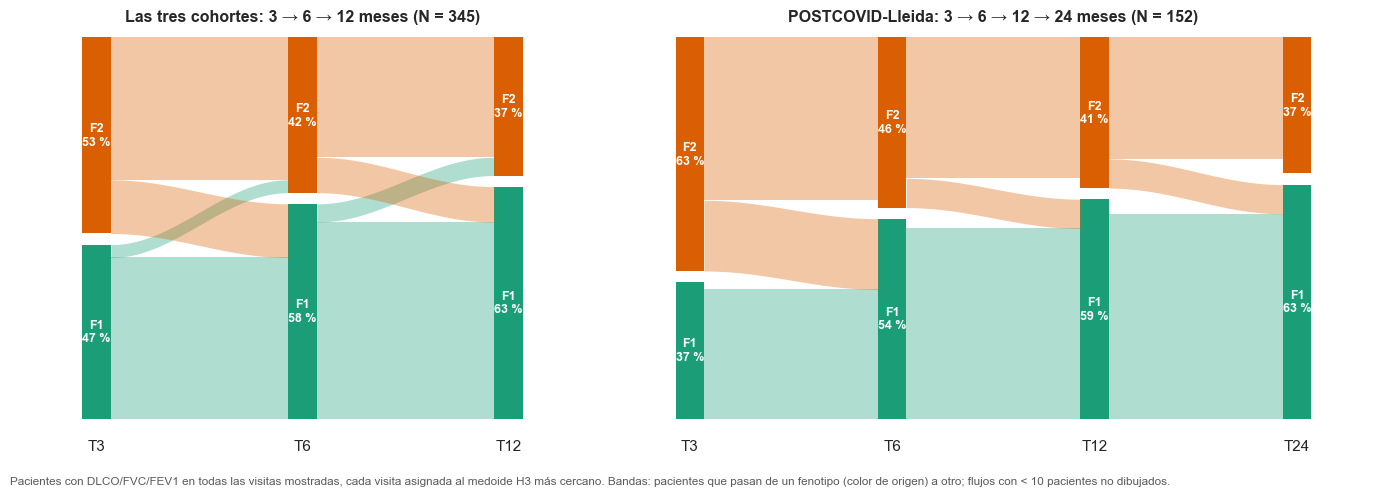

In [28]:
def aluvial(ax, etiquetas: pd.DataFrame, titulo: str) -> None:
    """Diagrama aluvial: bloques = % en cada fenotipo por visita; bandas = flujos entre visitas consecutivas.
    Los flujos de menos de N_MIN pacientes no se dibujan (privacidad)."""
    cols, n, hueco, ancho = list(etiquetas.columns), len(etiquetas), 0.03, 0.14
    pos = {}
    for j, c in enumerate(cols):
        y0 = 0.0
        for f in FEN:
            k = int((etiquetas[c] == f).sum()); h = k / n
            pos[(j, f)] = y0
            ax.add_patch(Rectangle((j - ancho / 2, y0), ancho, h, color=C_FEN[f], lw=0))
            ax.text(j, y0 + h / 2, f"{f}\n{100 * h:.0f} %", ha="center", va="center", fontsize=9, color="white", weight="bold")
            y0 += h + hueco
    for j in range(len(cols) - 1):
        sal = {f: pos[(j, f)] for f in FEN}; ent = {f: pos[(j + 1, f)] for f in FEN}
        for fa in FEN:
            for fb in FEN:
                k = int(((etiquetas[cols[j]] == fa) & (etiquetas[cols[j + 1]] == fb)).sum()); h = k / n
                if k >= N_MIN:
                    x = np.linspace(j + ancho / 2, j + 1 - ancho / 2, 60)
                    s = (1 - np.cos(np.pi * (x - x[0]) / (x[-1] - x[0]))) / 2
                    lo = sal[fa] + (ent[fb] - sal[fa]) * s
                    ax.fill_between(x, lo, lo + h, color=C_FEN[fa], alpha=0.35, lw=0)
                sal[fa] += h; ent[fb] += h
    ax.set_xticks(range(len(cols)), cols); ax.set_yticks([]); ax.set_xlim(-0.4, len(cols) - 0.6)
    ax.set_ylim(-0.02, 1 + hueco + 0.02); ax.grid(False); ax.set_title(f"{titulo} (N = {n})")
    for s_ in ["left", "bottom"]:
        ax.spines[s_].set_visible(False)


fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), gridspec_kw={"width_ratios": [3, 4]})
aluvial(axes[0], ETIQ[["T3", "T6", "T12"]].dropna(), "Las tres cohortes: 3 → 6 → 12 meses")
lle = ETIQ.loc[ETIQ.index[cohorte.reindex(ETIQ.index) == "POSTCOVID_LLEIDA"], ["T3", "T6", "T12", "T24"]].dropna()
aluvial(axes[1], lle, "POSTCOVID-Lleida: 3 → 6 → 12 → 24 meses")
nota(fig, "Pacientes con DLCO/FVC/FEV1 en todas las visitas mostradas, cada visita asignada al medoide H3 más cercano. "
          "Bandas: pacientes que pasan de un fenotipo (color de origen) a otro; flujos con < 10 pacientes no dibujados.")
plt.tight_layout(); guardar(fig, "transiciones"); plt.show()

Al año, el 76 % de los pacientes sigue en el mismo fenotipo y un 38 % de los F2 pasa a F1. Los medoides no tienen DLCO, así que esta reasignación depende sobre todo de la FVC.

### 3.5 Lleida hasta los 4 años

Solo Lleida tiene visitas después del año, así que lo vemos aparte.

Lleida, extensión: 1300 medidas de 457 pacientes; intercepto y pendiente aleatorios; convergió: True


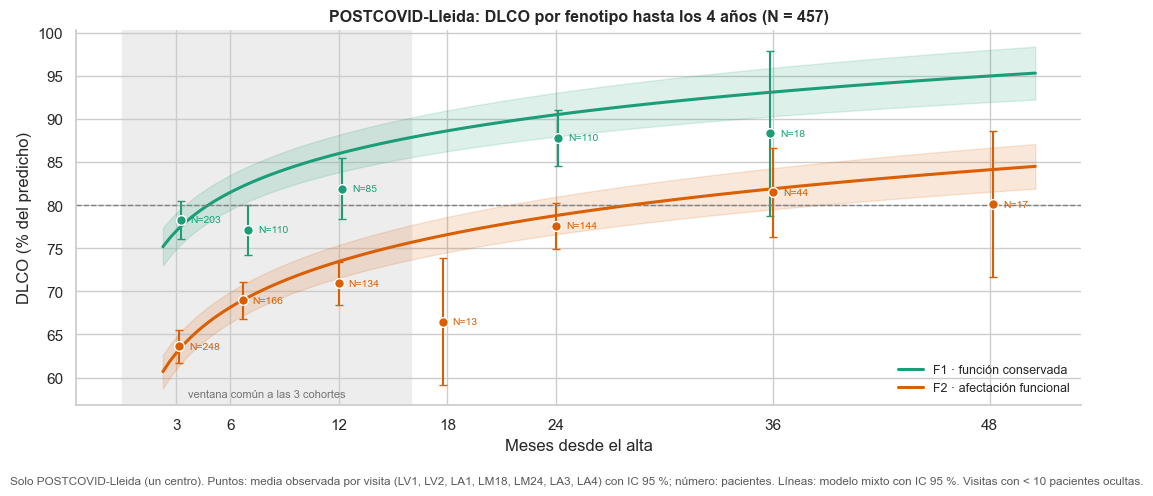

N      meses (mediana)       DLCO media      
fenotipo   F1   F2              F1    F2         F1    F2
visita                                                   
LV1       203  248             3.3   3.2       78.3  63.6
LV2       110  166             7.0   6.7       77.1  68.9
LA1        85  134            12.2  12.0       81.9  70.9
LM18      <10   13             NaN  17.7        NaN  66.5
LM24      110  144            24.1  24.0       87.8  77.6
LA3        18   44            35.9  36.0       88.3  81.5
LA4       <10   17             NaN  48.2        NaN  80.1

fenotipo,F1 · función conservada,F2 · afectación funcional,F2 − F1
meses,,,
3,77.0,62.8,-14.2 [-17.0 a -11.4]
6,81.5,68.2,-13.3 [-16.0 a -10.7]
12,86.0,73.5,-12.5 [-15.4 a -9.6]
18,88.6,76.6,-12.0 [-15.2 a -8.9]
24,90.5,78.8,-11.7 [-15.0 a -8.4]
36,93.1,81.9,-11.2 [-14.9 a -7.6]
48,95.0,84.1,-10.9 [-14.8 a -6.9]


In [29]:
EXT = TR["extension_lleida"]
fen_l = fenotipo[cohorte == "POSTCOVID_LLEIDA"]
L_ext = T.tabla_larga(medidas, fen_l, cohorte[fen_l.index], TR["variable"], (EXT["dias_min"], np.inf), DPM, MREF)
L_ext = L_ext[L_ext["visita"].isin(EXT["visitas"])]
mixto_ext, tipo_ext = T.ajustar_mixto(L_ext, FORMULA_C, TR["efectos_aleatorios"])
print(f"Lleida, extensión: {len(L_ext)} medidas de {L_ext['subject_id'].nunique()} pacientes; {tipo_ext}; convergió: {mixto_ext.converged}")

fig, ax = plt.subplots(figsize=(11, 4.8))
rej = np.linspace(np.percentile(L_ext["meses"], 2), L_ext["meses"].max(), 120)
filas = []
for f in FEN:
    pr = T.predicciones(mixto_ext, [f], list(rej), MREF)
    ax.plot(rej, pr["estimacion"], color=C_FEN[f], lw=2.2, label=NOMF[f])
    ax.fill_between(rej, pr["ic_inf"], pr["ic_sup"], color=C_FEN[f], alpha=0.15)
    for v in EXT["visitas"]:
        s = L_ext[(L_ext["fenotipo"] == f) & (L_ext["visita"] == v)]
        visible = len(s) >= N_MIN
        filas.append({"fenotipo": f, "visita": v, "N": len(s) if visible else f"<{N_MIN}",
                      "meses (mediana)": round(s["meses"].median(), 1) if visible else np.nan,
                      "DLCO media": round(s["valor"].mean(), 1) if visible else np.nan})
        if visible:
            m, lo, hi = media_ic(s["valor"]); x = s["meses"].median()
            ax.errorbar(x, m, yerr=[[m - lo], [hi - m]], fmt="o", color=C_FEN[f], mec="white", ms=7, capsize=3)
            ax.annotate(f"N={len(s)}", (x, m), textcoords="offset points", xytext=(7, 0),
                        ha="left", va="center", fontsize=7.5, color=C_FEN[f])
ax.axhline(U_DLCO, color="0.5", ls="--", lw=1); ax.axvspan(0, 16, color="0.93", zorder=0)
ax.text(8, ax.get_ylim()[0] + 1, "ventana común a las 3 cohortes", ha="center", fontsize=8, color="0.45")
ax.set_xticks([3, 6, 12, 18, 24, 36, 48]); ax.set_xlabel("Meses desde el alta"); ax.set_ylabel("DLCO (% del predicho)")
ax.set_title(f"POSTCOVID-Lleida: DLCO por fenotipo hasta los 4 años (N = {L_ext['subject_id'].nunique()})")
ax.legend(frameon=False, fontsize=9, loc="lower right")
nota(fig, "Solo POSTCOVID-Lleida (un centro). Puntos: media observada por visita (LV1, LV2, LA1, LM18, LM24, LA3, LA4) con IC 95 %; "
          "número: pacientes. Líneas: modelo mixto con IC 95 %. Visitas con < 10 pacientes ocultas.")
plt.tight_layout(); guardar(fig, "extension_lleida"); plt.show()

d_ext = T.diferencias(mixto_ext, "F1", "F2", EXT["meses_prediccion"], MREF)
p_ext = T.predicciones(mixto_ext, FEN, EXT["meses_prediccion"], MREF)
ext_tabla = p_ext.assign(v=lambda d: d["estimacion"].round(1)).pivot(index="meses", columns="fenotipo", values="v").rename(columns=NOMF)
ext_tabla["F2 − F1"] = [fmt_ic(r) for r in d_ext.to_dict("records")]
ext_tabla.to_csv(TAB / f"{PFX}_extension_lleida.csv")
display(pd.DataFrame(filas).pivot(index="visita", columns="fenotipo").reindex(EXT["visitas"]))
ext_tabla

La diferencia entre fenotipos se mantiene hasta los 4 años (−10,9 puntos a los 48 meses), aunque después de los 2 años hay pocos pacientes.

## 4. Predicción

Por último, queremos saber si podemos anticipar qué pacientes seguirán con la función pulmonar alterada al año. Primero lo intentamos con los datos del alta (notebooks 06 y 07), pero con cualquier modelo nos quedamos en un AUC de 0,63 aproximadamente (0,59–0,62 en cohortes no vistas), y añadir la fase aguda de CIBERESUCICOVID apenas mejora.

Por eso cambiamos el momento de la predicción a la visita de los 3 meses: de los pacientes con DLCO < 80 % a los 3 meses, ¿quién seguirá alterado al año?

### 4.1 Inicialización

In [30]:
import pickle
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

RAIZ = Path.cwd()
sys.path.insert(0, str(RAIZ))
from src import carga, fenotipado_perfil as FP, privacidad

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*converge.*")

cfg = carga.cargar_config()
PF = FP.perfil(cfg, "fenotipado_comun")        # mismas visitas, ventanas e inclusión que el clustering conjunto
COHORTES = PF["cohortes"]
SEMILLA = cfg["semilla"]
N_MIN = cfg["privacidad"]["n_minimo_celda"]
U_DLCO = cfg["umbrales_clinicos"]["dlco_pct"]
COLOR = cfg["colores_registro"]
ETQ = {"CIBERESUCICOVID": "CIBERESUCICOVID", "POSTCOVID_LLEIDA": "POSTCOVID-Lleida", "TENACITY": "TENACITY"}
DATOS = carga.RAIZ / cfg["rutas"]["procesados"]
FIG = RAIZ / cfg["rutas"]["figuras"] / "main"; FIG.mkdir(parents=True, exist_ok=True)
TAB = RAIZ / cfg["rutas"]["tablas"] / "main"; TAB.mkdir(parents=True, exist_ok=True)
PFX = "08_pv"

PARAM = cfg["primera_visita"]                 # parámetros del modelo (config.yaml)

FUN = ["dlco_T3", "fvc_T3", "fev1_T3"]
TIEMPO = ["dlco_T3_dias"]
ALTA = ["edad", "sexo", "estancia_hosp_dias", "nu_hta", "nu_diabetes", "nu_card_cronica", "nu_epoc",
        "nu_renal_cronica", "fumador_activo", "exfumador"]
NOMBRES = {"dlco_T3": "DLCO a 3 m", "fvc_T3": "FVC a 3 m", "fev1_T3": "FEV1 a 3 m",
           "dlco_T3_dias": "Días alta → prueba", "edad": "Edad", "sexo": "Mujer", "estancia_hosp_dias": "Estancia (días)",
           "nu_hta": "HTA", "nu_diabetes": "Diabetes", "nu_card_cronica": "Cardiopatía", "nu_epoc": "EPOC",
           "nu_renal_cronica": "Enf. renal", "fumador_activo": "Fumador activo", "exfumador": "Exfumador"}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold", "axes.titlesize": 11.5,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_columns", 40); pd.set_option("display.width", 200)


def nota(fig, texto: str) -> None:
    """Pie de figura con N y cohortes."""
    fig.text(0.01, -0.01, texto, fontsize=8.5, color="0.35", va="top", ha="left")


def guardar(fig, nombre: str) -> None:
    fig.savefig(FIG / f"{PFX}_{nombre}.png", bbox_inches="tight", dpi=150)


def edad_aproximada(tramo) -> float:
    """Punto medio del tramo de edad (misma regla que los modelos al alta)."""
    if not isinstance(tramo, str) or tramo.startswith("<"):
        return np.nan
    if tramo.endswith("+"):
        return float(tramo[:-1]) + 2
    lo, hi = tramo.split("-")
    return (float(lo) + float(hi)) / 2


def ic_wilson(k: int, n: int, z: float = 1.96) -> tuple[float, float]:
    """IC 95 % de Wilson para una proporción, en %."""
    if n == 0:
        return np.nan, np.nan
    p = k / n
    den = 1 + z ** 2 / n
    centro = (p + z ** 2 / (2 * n)) / den
    margen = z * np.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / den
    return 100 * (centro - margen), 100 * (centro + margen)


def ic_bootstrap(y: np.ndarray, p: np.ndarray, metrica, n: int = PARAM["n_bootstrap"],
                 peso: np.ndarray | None = None) -> tuple[float, float]:
    """IC 95 % bootstrap de una métrica (remuestreo de pacientes)."""
    rng = np.random.default_rng(SEMILLA); vals = []
    for _ in range(n):
        idx = rng.integers(0, len(y), len(y))
        if len(np.unique(y[idx])) == 2:
            vals.append(metrica(y[idx], p[idx]) if peso is None else metrica(y[idx], p[idx], sample_weight=peso[idx]))
    return tuple(np.percentile(vals, [2.5, 97.5]))


def dif_auc(y: np.ndarray, p1: np.ndarray, p2: np.ndarray, n: int = PARAM["n_bootstrap"]) -> tuple:
    """ΔAUC (p1 − p2) emparejado: estimación, IC 95 % bootstrap y p bilateral."""
    rng = np.random.default_rng(SEMILLA); difs = []
    for _ in range(n):
        idx = rng.integers(0, len(y), len(y))
        if len(np.unique(y[idx])) == 2:
            difs.append(roc_auc_score(y[idx], p1[idx]) - roc_auc_score(y[idx], p2[idx]))
    difs = np.array(difs)
    return (roc_auc_score(y, p1) - roc_auc_score(y, p2), np.percentile(difs, [2.5, 97.5]),
            min(1.0, 2 * min((difs <= 0).mean(), (difs >= 0).mean())))

### 4.2 Población

Partimos de los pacientes del horizonte H3 del clustering conjunto y les añadimos su DLCO de la visita anual. Nos quedamos con los que tienen la DLCO alterada a los 3 meses y medida al año.

In [31]:
pacientes = pd.read_parquet(DATOS / "pacientes.parquet")
medidas = pd.read_parquet(DATOS / "medidas.parquet")
visitas_ten = pd.read_parquet(DATOS / "visitas_tenacity.parquet")


def primera_en_visita(cohorte: str, variable: str, visita: str) -> pd.DataFrame:
    """Primera medida válida de `variable` en la visita genérica `visita` (misma regla que FP.construir_variables)."""
    m = FP.medidas_por_visita(medidas, PF, cohorte, [variable])
    m = m[m["visita_c"] == visita].sort_values("dias_alta")
    f = m.groupby("subject_id")[["valor", "dias_alta"]].first()
    return f.rename(columns={"valor": f"{variable}_{visita}", "dias_alta": f"{variable}_{visita}_dias"})


partes = []
for c in COHORTES:
    t3, _ = FP.construir_variables(medidas, pacientes, cfg, PF, "H3", c)       # inclusión del clustering conjunto
    d3, d12 = primera_en_visita(c, "dlco", "T3"), primera_en_visita(c, "dlco", "T12")
    comun = t3["dlco_T3"].dropna().index
    assert np.allclose(t3.loc[comun, "dlco_T3"], d3.loc[comun, "dlco_T3"]), "regla de la primera medida distinta"
    partes.append(t3[["cohorte_analisis", "centro_id", *FUN]].join(d3[["dlco_T3_dias"]]).join(d12))
base = pd.concat(partes)
assert base.index.is_unique, "paciente duplicado entre cohortes"

p = pacientes.set_index("subject_id").loc[base.index]
base["cohorte"] = base["cohorte_analisis"].astype(str)
base["edad"] = p["edad_tramo5"].map(edad_aproximada)
for v in ["sexo", "estancia_hosp_dias", "nu_hta", "nu_diabetes", "nu_card_cronica", "nu_epoc", "nu_renal_cronica"]:
    base[v] = p[v].astype(float)
base["fumador_activo"] = (p["nu_tabaquismo"] == 1).astype(float).where(p["nu_tabaquismo"].notna())
base["exfumador"] = (p["nu_tabaquismo"] == 2).astype(float).where(p["nu_tabaquismo"].notna())
base["alterada_3m"] = base["dlco_T3"] < U_DLCO
base["con_12m"] = base["dlco_T12"].notna()
base["persiste"] = (base["dlco_T12"] < U_DLCO).astype(float).where(base["con_12m"])

pasos = {
    "1. Incluidos en H3 (clustering conjunto)": pd.Series(True, index=base.index),
    "2. Con DLCO a 3 meses": base["dlco_T3"].notna(),
    "3. DLCO < 80 % a 3 meses": base["alterada_3m"],
    "4. … y con DLCO a 12 meses (población del modelo)": base["alterada_3m"] & base["con_12m"],
}
flujo = pd.DataFrame({k: v.groupby(base["cohorte"]).sum() for k, v in pasos.items()}).T[COHORTES]
flujo["Total"] = flujo.sum(axis=1)
flujo = flujo.astype(int).rename(columns=ETQ)
flujo.to_csv(TAB / f"{PFX}_flujo.csv")

A = base[base["alterada_3m"] & base["con_12m"]].copy()
y = A["persiste"].astype(int).to_numpy()
print(f"Población del modelo: {len(A)} pacientes; persisten con DLCO < {U_DLCO} % al año: {y.mean():.1%}")
privacidad.suprimir_celdas(flujo, N_MIN)

Población del modelo: 361 pacientes; persisten con DLCO < 80 % al año: 70.1%


cohorte,CIBERESUCICOVID,POSTCOVID-Lleida,TENACITY,Total
1. Incluidos en H3 (clustering conjunto),956,464,154,1574
2. Con DLCO a 3 meses,767,451,151,1369
3. DLCO < 80 % a 3 meses,498,322,74,894
4. … y con DLCO a 12 meses (población del modelo),161,176,24,361


### 4.3 La DLCO a los 3 meses

Antes de entrenar ningún modelo, miramos cuánto anticipa la DLCO a los 3 meses por sí sola la del año, en todos los pacientes que tienen las dos medidas.

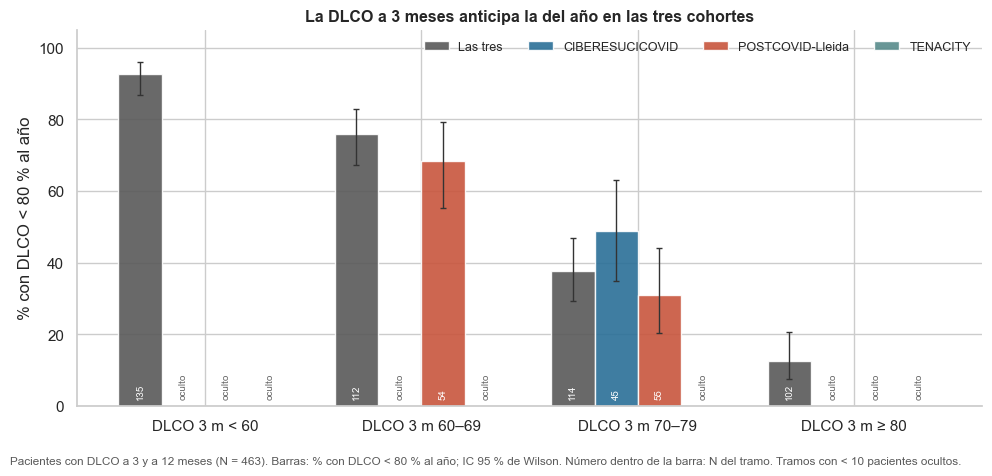

,N,% DLCO < 80 al año,ROC-AUC de la DLCO a 3 m sola,IC95
grupo,,,,
Las tres,463,57.5,0.874,0.84–0.90
CIBERESUCICOVID,197,67.0,0.857,0.79–0.91
POSTCOVID-Lleida,215,56.3,0.874,0.82–0.91
TENACITY,51,25.5,0.919,0.83–0.99


In [32]:
ambas = base[base["dlco_T3"].notna() & base["con_12m"]].copy()
bordes = PARAM["bandas_dlco"] + [np.inf]
etq_bandas = [f"< {bordes[1]}"] + [f"{a}–{b - 1}" for a, b in zip(bordes[1:-2], bordes[2:-1])] + [f"≥ {bordes[-2]}"]
ambas["tramo"] = pd.cut(ambas["dlco_T3"], bordes, right=False, labels=etq_bandas)

filas = []
for grupo, g in [("Las tres", ambas), *[(ETQ[c], ambas[ambas["cohorte"] == c]) for c in COHORTES]]:
    for tramo, t in g.groupby("tramo", observed=False):
        n, k = len(t), int(t["persiste"].sum())
        lo, hi = ic_wilson(k, n)
        visible = n >= N_MIN and not (0 < k < N_MIN or 0 < n - k < N_MIN)
        filas.append({"grupo": grupo, "tramo DLCO 3 m": tramo, "N": n,
                      "% DLCO < 80 al año": round(100 * k / n, 1) if visible else np.nan,
                      "IC95 inf": round(lo, 1) if visible else np.nan, "IC95 sup": round(hi, 1) if visible else np.nan})
tramos = pd.DataFrame(filas)
tramos.to_csv(TAB / f"{PFX}_tramos_todos.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 4.6))
grupos = ["Las tres", *[ETQ[c] for c in COHORTES]]
colores = {"Las tres": "0.35", **{ETQ[c]: COLOR[c] for c in COHORTES}}
ancho = 0.8 / len(grupos)
for i, gr in enumerate(grupos):
    t = tramos[tramos["grupo"] == gr].reset_index(drop=True)
    x = np.arange(len(etq_bandas)) + (i - (len(grupos) - 1) / 2) * ancho
    v = t["% DLCO < 80 al año"].to_numpy(float)
    ax.bar(x, np.nan_to_num(v), ancho, color=colores[gr], label=gr, alpha=0.9)
    ok = ~np.isnan(v)
    ax.errorbar(x[ok], v[ok], yerr=[v[ok] - t.loc[ok, "IC95 inf"], t.loc[ok, "IC95 sup"] - v[ok]],
                fmt="none", ecolor="0.2", capsize=2.5, lw=1)
    for xi, n, vi in zip(x, t["N"], v):
        visible = not np.isnan(vi)
        ax.text(xi, 2, f"{n}" if visible else "oculto", ha="center", va="bottom", fontsize=7,
                color="white" if visible else "0.4", rotation=90)
ax.set_xticks(range(len(etq_bandas)), [f"DLCO 3 m {e}" for e in etq_bandas])
ax.set_ylabel("% con DLCO < 80 % al año"); ax.set_ylim(0, 105)
ax.set_title("La DLCO a 3 meses anticipa la del año en las tres cohortes")
ax.legend(frameon=False, fontsize=9, ncol=4, loc="upper right")
nota(fig, f"Pacientes con DLCO a 3 y a 12 meses (N = {len(ambas)}). Barras: % con DLCO < 80 % al año; IC 95 % de Wilson. "
          "Número dentro de la barra: N del tramo. Tramos con < 10 pacientes ocultos.")
plt.tight_layout(); guardar(fig, "tramos_todos"); plt.show()

filas = []
for grupo, g in [("Las tres", ambas), *[(ETQ[c], ambas[ambas["cohorte"] == c]) for c in COHORTES]]:
    yy, ss = g["persiste"].to_numpy(int), -g["dlco_T3"].to_numpy()
    lo, hi = ic_bootstrap(yy, ss, roc_auc_score)
    filas.append({"grupo": grupo, "N": len(g), "% DLCO < 80 al año": round(100 * yy.mean(), 1),
                  "ROC-AUC de la DLCO a 3 m sola": round(roc_auc_score(yy, ss), 3), "IC95": f"{lo:.2f}–{hi:.2f}"})
auc_todos = pd.DataFrame(filas).set_index("grupo")
auc_todos.to_csv(TAB / f"{PFX}_auc_dlco_todos.csv")
auc_todos

Con DLCO ≥ 80 % a los 3 meses casi nadie está alterado al año (13 %), y la DLCO sola ya tiene un AUC de 0,87. La duda real está en los alterados, así que los modelos los entrenamos solo con ellos.

### 4.4 Modelos

Comparamos 4 modelos, de menos a más complejo: la DLCO a 3 meses sola (referencia), la función a 3 meses (DLCO, FVC y FEV1), un árbol de profundidad 3 y una logística L1 con la función y los datos del alta. Validamos dejando fuera cada cohorte: entrenamos con dos y evaluamos en la tercera. Solo nos quedamos con un modelo más complejo si mejora el AUC de la referencia con un IC que no incluya el 0.

In [33]:
def logistica(cols: list[str], l1: bool = False) -> Pipeline:
    """Imputación por mediana + estandarización + logística (L2 por defecto; L1 con C por validación cruzada)."""
    if l1:
        lr = LogisticRegressionCV(Cs=PARAM["l1_Cs"], penalty="l1", solver="liblinear", scoring="neg_log_loss",
                                  cv=StratifiedKFold(PARAM["pliegues_internos"], shuffle=True, random_state=SEMILLA),
                                  max_iter=5000)
    else:
        lr = LogisticRegression(max_iter=5000)
    return Pipeline([("imp", SimpleImputer(strategy="median")), ("esc", StandardScaler()), ("lr", lr)])


def arbol() -> Pipeline:
    return Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("arbol", DecisionTreeClassifier(max_depth=PARAM["arbol_profundidad"],
                                                      min_samples_leaf=PARAM["arbol_min_hoja"], random_state=SEMILLA))])


COMPLETO = FUN + TIEMPO + ALTA
MODELOS = {                                   # en orden de complejidad (el contrato elige el más sencillo)
    "DLCO a 3 m sola": (logistica(["dlco_T3"]), ["dlco_T3"]),
    "Función a 3 m": (logistica(FUN), FUN),
    "Árbol (prof. ≤ 3)": (arbol(), COMPLETO),
    "Función + alta (L1)": (logistica(COMPLETO, l1=True), COMPLETO),
}
REF = "DLCO a 3 m sola"


def predecir_loco(datos: pd.DataFrame, yv: np.ndarray) -> pd.DataFrame:
    """Probabilidad de persistencia de cada paciente con modelos entrenados SIN su cohorte."""
    pred = pd.DataFrame(np.nan, index=datos.index, columns=list(MODELOS))
    for c in COHORTES:
        fuera = (datos["cohorte"] == c).to_numpy()
        for nombre, (est, cols) in MODELOS.items():
            m = clone(est).fit(datos.loc[~fuera, cols], yv[~fuera])
            pred.loc[fuera, nombre] = m.predict_proba(datos.loc[fuera, cols])[:, 1]
    return pred


def pendiente_calibracion(yv: np.ndarray, p: np.ndarray) -> float:
    """Pendiente de calibración (1 = ideal; < 1 = predicciones demasiado extremas)."""
    q = np.clip(p, 1e-6, 1 - 1e-6)
    try:
        return float(sm.Logit(yv, sm.add_constant(np.log(q / (1 - q)))).fit(disp=0).params[1])
    except Exception:
        return np.nan


P = predecir_loco(A, y)
GRUPOS = {"Agrupado": np.ones(len(A), bool), **{ETQ[c]: (A["cohorte"] == c).to_numpy() for c in COHORTES}}
filas = []
for grupo, m in GRUPOS.items():
    for nombre in MODELOS:
        yy, pp = y[m], P[nombre].to_numpy()[m]
        lo, hi = ic_bootstrap(yy, pp, roc_auc_score)
        filas.append({"evaluada en": grupo, "modelo": nombre, "N": int(m.sum()), "% persiste": round(100 * yy.mean(), 1),
                      "ROC-AUC": round(roc_auc_score(yy, pp), 3), "IC95": f"{lo:.2f}–{hi:.2f}", "auc_lo": lo, "auc_hi": hi,
                      "PR-AUC": round(average_precision_score(yy, pp), 3), "Brier": round(brier_score_loss(yy, pp), 3),
                      "Observado − predicho (pp)": round(100 * (yy.mean() - pp.mean()), 1),
                      "Pendiente de calibración": round(pendiente_calibracion(yy, pp), 2)})
metricas = pd.DataFrame(filas).set_index(["evaluada en", "modelo"])
metricas.drop(columns=["auc_lo", "auc_hi"]).to_csv(TAB / f"{PFX}_metricas_loco.csv")
metricas.drop(columns=["auc_lo", "auc_hi"])

N  % persiste  ROC-AUC       IC95  PR-AUC  Brier  Observado − predicho (pp)  Pendiente de calibración
evaluada en      modelo                                                                                                                      
Agrupado         DLCO a 3 m sola      361        70.1    0.792  0.74–0.84   0.904  0.166                        0.0                      0.87
                 Función a 3 m        361        70.1    0.794  0.75–0.84   0.906  0.165                        0.3                      0.88
                 Árbol (prof. ≤ 3)    361        70.1    0.762  0.71–0.81   0.876  0.188                       -1.2                      0.41
                 Función + alta (L1)  361        70.1    0.775  0.72–0.82   0.899  0.172                        2.3                      0.92
CIBERESUCICOVID  DLCO a 3 m sola      161        77.6    0.793  0.71–0.88   0.921  0.161                       12.0                      0.83
                 Función a 3 m        161        77.6    0.796  0.71–0.88   0.924  0.161                       12.3                      0.82
                 Árbol (prof. ≤ 3)    161        77.6    0.758  0.66–0.85   0.888  0.185                       13.2                      0.47
                 Función + alta (L1)  161        77.6    0.808  0.72–0.89   0.927  0.169                       16.7                      1.06
POSTCOVID-Lleida DLCO a 3 m sola      176        65.9    0.843  0.78–0.90   0.917  0.170                       -9.8                      1.25
                 Función a 3 m        176        65.9    0.842  0.78–0.90   0.919  0.166                       -8.6                      1.26
                 Árbol (prof. ≤ 3)    176        65.9    0.824  0.76–0.88   0.878  0.192                      -12.9                      0.44
                 Función + alta (L1)  176        65.9    0.847  0.79–0.90   0.922  0.172                       -9.3                      1.60
TENACITY         DLCO a 3 m sola       24        50.0    0.830  0.65–0.98   0.863  0.182                       -8.5                      1.37
                 Función a 3 m         24        50.0    0.875  0.72–1.00   0.885  0.181                      -15.0                      1.64
                 Árbol (prof. ≤ 3)     24        50.0    0.809  0.61–0.95   0.810  0.186                      -11.5                      1.06
                 Función + alta (L1)   24        50.0    0.826  0.63–0.98   0.869  0.190                       -9.0                      1.32

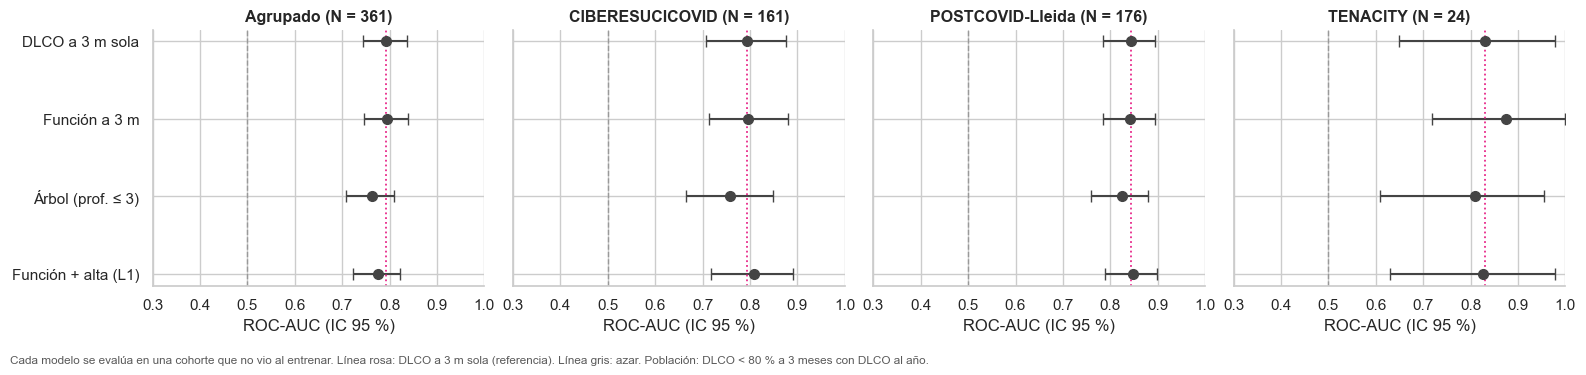

Modelos que mejoran a la referencia (IC del ΔAUC agrupado > 0): ninguno
Modelo final según el contrato: DLCO a 3 m sola


ΔAUC  IC95 inferior  IC95 superior      p
evaluada en      comparación                                                                      
Agrupado         Función a 3 m − DLCO a 3 m sola        0.003         -0.006          0.011  0.582
                 Árbol (prof. ≤ 3) − DLCO a 3 m sola   -0.030         -0.059          0.002  0.064
                 Función + alta (L1) − DLCO a 3 m sola -0.016         -0.034         -0.002  0.030
CIBERESUCICOVID  Función a 3 m − DLCO a 3 m sola        0.003         -0.008          0.014  0.562
                 Árbol (prof. ≤ 3) − DLCO a 3 m sola   -0.035         -0.075          0.003  0.090
                 Función + alta (L1) − DLCO a 3 m sola  0.016         -0.013          0.043  0.236
POSTCOVID-Lleida Función a 3 m − DLCO a 3 m sola       -0.001         -0.011          0.008  0.820
                 Árbol (prof. ≤ 3) − DLCO a 3 m sola   -0.019         -0.064          0.022  0.368
                 Función + alta (L1) − DLCO a 3 m sola  0.004         -0.009          0.018  0.554
TENACITY         Función a 3 m − DLCO a 3 m sola        0.045         -0.022          0.140  0.290
                 Árbol (prof. ≤ 3) − DLCO a 3 m sola   -0.021         -0.164          0.132  0.766
                 Función + alta (L1) − DLCO a 3 m sola -0.003         -0.063          0.049  0.910

In [34]:
fig, axes = plt.subplots(1, len(GRUPOS), figsize=(16, 3.6), sharey=True)
nombres = list(MODELOS)[::-1]
for ax, grupo in zip(axes, GRUPOS):
    t = metricas.loc[grupo].loc[nombres]
    ax.errorbar(t["ROC-AUC"], range(len(t)), xerr=[t["ROC-AUC"] - t["auc_lo"], t["auc_hi"] - t["ROC-AUC"]],
                fmt="o", ms=7, capsize=4, color="#444")
    ax.axvline(t.loc[REF, "ROC-AUC"], color="#e7298a", ls=":", lw=1.3)
    ax.axvline(0.5, color="0.6", ls="--", lw=1)
    ax.set_xlim(0.3, 1.0); ax.set_title(f"{grupo} (N = {int(t['N'].iloc[0])})"); ax.set_xlabel("ROC-AUC (IC 95 %)")
axes[0].set_yticks(range(len(nombres)), nombres)
nota(fig, "Cada modelo se evalúa en una cohorte que no vio al entrenar. Línea rosa: DLCO a 3 m sola (referencia). "
          "Línea gris: azar. Población: DLCO < 80 % a 3 meses con DLCO al año.")
plt.tight_layout(); guardar(fig, "auc_loco"); plt.show()

filas = []
for grupo, m in GRUPOS.items():
    for nombre in list(MODELOS)[1:]:
        d, ic, pv = dif_auc(y[m], P[nombre].to_numpy()[m], P[REF].to_numpy()[m])
        filas.append({"evaluada en": grupo, "comparación": f"{nombre} − {REF}", "ΔAUC": round(d, 3),
                      "IC95 inferior": round(ic[0], 3), "IC95 superior": round(ic[1], 3), "p": round(pv, 3)})
delta = pd.DataFrame(filas).set_index(["evaluada en", "comparación"])
delta.to_csv(TAB / f"{PFX}_delta_auc.csv")

# Contrato: el más sencillo que mejore a la referencia en el AUC agrupado con IC que excluya 0
mejoran = [n for n in list(MODELOS)[1:] if delta.loc[("Agrupado", f"{n} − {REF}"), "IC95 inferior"] > 0]
MODELO_FINAL = mejoran[0] if mejoran else REF
print(f"Modelos que mejoran a la referencia (IC del ΔAUC agrupado > 0): {mejoran or 'ninguno'}")
print(f"Modelo final según el contrato: {MODELO_FINAL}")
delta

Ningún modelo mejora a la DLCO sola, que tiene un AUC de 0,79 en cohortes no vistas. Ni la espirometría ni los datos del alta aportan nada cuando ya tenemos la DLCO, así que nos quedamos con la regla más simple.

### 4.5 Tabla para la consulta

Resumimos el resultado en una tabla por tramos de DLCO a los 3 meses y la aplicamos a tres pacientes ficticios.

In [35]:
finales = {n: clone(est).fit(A[cols], y) for n, (est, cols) in MODELOS.items()}
A["tramo"] = pd.cut(A["dlco_T3"], PARAM["bandas_dlco"], right=False,
                    labels=[f"< {PARAM['bandas_dlco'][1]}"] + [f"{a}–{b - 1}" for a, b in
                                                               zip(PARAM["bandas_dlco"][1:-1], PARAM["bandas_dlco"][2:])])

filas = []
for grupo, g in [("Las tres", A), *[(ETQ[c], A[A["cohorte"] == c]) for c in COHORTES]]:
    for tramo, t in g.groupby("tramo", observed=False):
        n, k = len(t), int((t["persiste"] == 0).sum())
        lo, hi = ic_wilson(k, n)
        visible = n >= N_MIN and not (0 < k < N_MIN or 0 < n - k < N_MIN)
        filas.append({"grupo": grupo, "DLCO a 3 m": tramo, "N": n if n >= N_MIN else np.nan,
                      "% se recupera al año": f"{100 * k / n:.0f} %" if visible else "suprimido (N < 10)",
                      "IC 95 %": f"{lo:.0f}–{hi:.0f} %" if visible else ""})
bolsillo = pd.DataFrame(filas).astype({"N": "Int64"}).set_index(["grupo", "DLCO a 3 m"])
bolsillo.to_csv(TAB / f"{PFX}_tabla_bolsillo.csv")
display(bolsillo)

modelo_final = finales[MODELO_FINAL]
cols_final = MODELOS[MODELO_FINAL][1]
ejemplos = pd.DataFrame([
    {"dlco_T3": 55, "fvc_T3": 70, "fev1_T3": 72, "dlco_T3_dias": 95, "edad": 67, "sexo": 0, "estancia_hosp_dias": 40,
     "nu_hta": 1, "nu_diabetes": 1, "nu_card_cronica": 0, "nu_epoc": 0, "nu_renal_cronica": 0, "fumador_activo": 0, "exfumador": 1},
    {"dlco_T3": 66, "fvc_T3": 85, "fev1_T3": 88, "dlco_T3_dias": 95, "edad": 57, "sexo": 1, "estancia_hosp_dias": 25,
     "nu_hta": 0, "nu_diabetes": 0, "nu_card_cronica": 0, "nu_epoc": 0, "nu_renal_cronica": 0, "fumador_activo": 0, "exfumador": 0},
    {"dlco_T3": 76, "fvc_T3": 95, "fev1_T3": 97, "dlco_T3_dias": 95, "edad": 52, "sexo": 0, "estancia_hosp_dias": 15,
     "nu_hta": 0, "nu_diabetes": 0, "nu_card_cronica": 0, "nu_epoc": 0, "nu_renal_cronica": 0, "fumador_activo": 0, "exfumador": 0},
], index=["A · DLCO 55 %, FVC 70 %", "B · DLCO 66 %, FVC 85 %", "C · DLCO 76 %, FVC 95 %"])
ejemplos["P(sigue alterado al año)"] = modelo_final.predict_proba(ejemplos[cols_final])[:, 1].round(2)
print(f"Modelo final: {MODELO_FINAL}. Pacientes ficticios, no reales:")
ejemplos[["dlco_T3", "fvc_T3", "P(sigue alterado al año)"]]

N % se recupera al año  IC 95 %
grupo            DLCO a 3 m                                    
Las tres         < 60         135                  7 %   4–13 %
                 60–69        112                 24 %  17–33 %
                 70–79        114                 62 %  53–71 %
CIBERESUCICOVID  < 60          63   suprimido (N < 10)         
                 60–69         53   suprimido (N < 10)         
                 70–79         45                 51 %  37–65 %
POSTCOVID-Lleida < 60          67   suprimido (N < 10)         
                 60–69         54                 31 %  21–45 %
                 70–79         55                 69 %  56–80 %
TENACITY         < 60        <NA>   suprimido (N < 10)         
                 60–69       <NA>   suprimido (N < 10)         
                 70–79         14   suprimido (N < 10)

Modelo final: DLCO a 3 m sola. Pacientes ficticios, no reales:


,dlco_T3,fvc_T3,P(sigue alterado al año)
"A · DLCO 55 %, FVC 70 %",55,70,0.91
"B · DLCO 66 %, FVC 85 %",66,85,0.68
"C · DLCO 76 %, FVC 95 %",76,95,0.35


De los pacientes con DLCO < 80 % a los 3 meses, se recupera al año el 7 % si la DLCO es menor de 60 %, el 24 % si está entre 60 y 69 % y el 62 % si está entre 70 y 79 %. La DLCO de la visita de los 3 meses es la que decide a quién hay que seguir de cerca.

## 5. Conclusiones

1. **Hay un fenotipo que viaja.** Con las variables que las tres cohortes miden igual (DLCO, FVC y FEV1), a los 3 meses salen dos fenotipos: F1 «función conservada» y F2 «afectación funcional». Son estables, se reproducen al dejar fuera cada cohorte y se reconocen con una sola pregunta: ¿FVC a los 3 meses ≤ 83 %? Los fenotipos de síntomas de CIBERESUCICOVID, en cambio, no se reproducen en otras cohortes.
2. **Evolucionan distinto.** Los dos mejoran, pero al año F2 sigue 11,5 puntos de DLCO por debajo de F1 y por debajo del 80 %, en todas las cohortes.
3. **Se pueden predecir en la visita de los 3 meses, no al alta.** Con los datos del alta nos quedamos en un AUC de 0,63. A los 3 meses, la DLCO sola predice quién seguirá alterado al año (AUC 0,79 en cohortes no vistas) y ningún modelo más complejo la mejora.

**Para la consulta:** la visita de los 3 meses es la que decide. En F1 basta con un control al año. En F2 hace falta seguimiento más allá del año, y dentro de F2 la DLCO indica quién se recuperará.

**Limitaciones:** hay pocas variables comunes entre cohortes (por eso el fenotipo es solo respiratorio), el abandono en las visitas tardías es informativo, TENACITY es pequeña y Lleida es un solo centro. El detalle está en `docs/informe.md`, y el uso de IA en `docs/declaracion_IA.md`.